<div align="center">
  <h1><b>Prediksi Customer Churn Menggunakan Model Machine Leraning pada Industri Telekomunikasi</b></h1>
  <b>Muhammad Hafizh Hariyanto</b>
</div>

# Pendahuluan

Churn pelanggan merupakan tantangan utama dalam industri telekomunikasi karena berdampak langsung pada pendapatan dan profitabilitas perusahaan. Oleh karena itu, prediksi churn menjadi aspek krusial dalam strategi retensi pelanggan. Proyek ini bertujuan untuk mengembangkan model machine learning yang mampu memprediksi pelanggan berisiko churn dengan akurasi tinggi, sehingga tim bisnis dapat mengambil tindakan pencegahan secara proaktif dan efisien.

# 1. Business Understanding

## 1.1. Latar Belakang Bisnis

**ABC Telco** merupakan perusahaan telekomunikasi yang menyediakan layanan internet, telepon, dan berbagai layanan tambahan digital. Industri telekomunikasi merupakan salah satu sektor yang memiliki tingkat persaingan sangat tinggi. Pelanggan memiliki kemudahan untuk berpindah ke operator lain kapan saja baik karena harga, kualitas jaringan, maupun layanan pelanggan yang lebih baik. Fenomena ini dikenal sebagai **customer churn** kondisi di mana pelanggan berhenti menggunakan layanan suatu perusahaan.

Tingkat churn di industri telekomunikasi secara global berkisar antara **15% hingga 25% per tahun**. Setiap pelanggan yang hilang tidak hanya berarti hilangnya pendapatan berulang, tetapi juga biaya untuk mencari penggantinya.Menurut Harvard Business Review, biaya mendapatkan pelanggan baru bisa 5 hingga 25 kali lebih mahal dibandingkan mempertahankan pelanggan yang sudah ada [(Gallo, HBR, 2014)](https://hbr.org/2014/10/the-value-of-keeping-the-right-customers). Oleh karena itu, kemampuan memprediksi pelanggan yang berisiko churn **sebelum mereka benar-benar berhenti berlangganan** menjadi sangat penting bagi perusahaan sebagai dasar pengambilan keputusan retensi yang lebih proaktif dan berbasis data.

## 1.2. Rumusan Masalah
Perusahaan telekomunikasi mengalami tingkat churn sebesar 26.7%, di mana 1.316 dari 4.930 pelanggan berhenti berlangganan. Tanpa sistem prediksi yang memadai, perusahaan hanya dapat melakukan intervensi setelah pelanggan benar-benar churn, sehingga upaya retensi menjadi tidak efektif.Selain itu, tanpa model prediktif, tim retensi berpotensi menghubungi pelanggan secara acak, yang menyebabkan pemborosan biaya karena banyak pelanggan yang sebenarnya tidak berisiko churn tetap diberikan penawaran retensi.

Berdasarkan kondisi tersebut, pertanyaan penelitian yang diajukan adalah:
1. Bagaimana membangun model prediksi churn yang mampu **mengidentifikasi pelanggan berisiko** secara akurat?
2. Apakah pendekatan **Machine Learning lebih efektif dibanding metode rule-based** dalam menekan biaya retensi dan kerugian bisnis?

## 1.3 Tujuan
Membangun model machine learning klasifikasi yang mampu:
1. Mengembangkan model machine learning yang mampu ****mengidentifikasi pelanggan berisiko churn** secara akurat sebelum benar-benar berhenti.
2. **Mengevaluasi efektivitas model tersebut dibandingkan pendekatan rule-based** dalam menekan biaya retensi dan kerugian bisnis.
Dengan model ini, bisnis dapat mengambil langkah preventif lebih awal untuk mempertahankan pelanggan dan meningkatkan profitabilitas jangka panjang.

## 1.4 Pendekatan Analitik
Karena target variabel yang ingin diprediksi adalah **Churn (Yes/No)** — yaitu variabel kategorik biner — maka pendekatan yang digunakan adalah **Supervised Machine Learning: Binary Classification**.

Model akan mempelajari pola dari data historis pelanggan (fitur seperti tenure, jenis kontrak, layanan yang digunakan, dll.) dan menghasilkan prediksi apakah seorang pelanggan akan churn atau tidak.

## 1.5 Evaluation Metrics
Dalam konteks bisnis ini, **False Negative (FN)** — yaitu pelanggan yang sebenarnya churn tapi diprediksi tidak churn — memiliki dampak yang **lebih besar** daripada False Positive (FP).

**Kenapa?**
- **FN (Miss):** Pelanggan churn tidak tertangkap → perusahaan kehilangan pelanggan secara permanen → kehilangan revenue jangka panjang
- **FP (False Alarm):** Pelanggan tidak churn tapi diprediksi churn → perusahaan menghubungi pelanggan yang tidak perlu → ada biaya retensi tidak perlu, tapi pelanggan tetap ada

Karena kedua jenis error ini memiliki dampak yang berbeda, dibutuhkan metrik yang dapat **menyeimbangkan Recall dan Precision namun tetap memberikan bobot lebih besar pada Recall**. Metrik yang tepat adalah **F2 Score (F-beta dengan β=2)**.

$$F_2 = 5 \cdot \frac{Precision \times Recall}{4 \cdot Precision + Recall}$$

**Target:** F2 Score ≥ 0.70 untuk kelas Churn (positif)


### Import Modules

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
warnings.filterwarnings('ignore')

# Statistik
import scipy.stats as stats

# Preprocessing
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, RobustScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer

# Model Selection
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.base import clone

# Feature Selection
from sklearn.feature_selection import SelectKBest, f_classif

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    ExtraTreesClassifier, BaggingClassifier
)
from xgboost import XGBClassifier
import lightgbm as lgb
from catboost import CatBoostClassifier

# Resampling
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

# Metrics
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, auc,
    f1_score, fbeta_score, recall_score, precision_score,
    accuracy_score, ConfusionMatrixDisplay, make_scorer,
    precision_recall_curve
)

# SHAP
import shap
import pickle
import json

# Display settings
pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')

# 2. Data Understanding

## 2.1. Read Dataset

In [2]:
df = pd.read_csv('data_telco_customer_churn.csv')
print(f'Jumlah Baris: {df.shape[0]}')
print(f'Jumlah Kolom: {df.shape[1]}')
df.head()

Jumlah Baris: 4930
Jumlah Kolom: 11


,Dependents,tenure,OnlineSecurity,OnlineBackup,InternetService,DeviceProtection,TechSupport,Contract,PaperlessBilling,MonthlyCharges,Churn
0,Yes,9,No,No,DSL,Yes,Yes,Month-to-month,Yes,72.90,Yes
1,No,14,No,Yes,Fiber optic,Yes,No,Month-to-month,Yes,82.65,No
2,No,64,Yes,No,DSL,Yes,Yes,Two year,No,47.85,Yes
3,No,72,Yes,Yes,DSL,Yes,Yes,Two year,No,69.65,No
4,No,3,No internet service,No internet service,No,No internet service,No internet service,Month-to-month,Yes,23.60,No


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4930 entries, 0 to 4929
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Dependents        4930 non-null   object 
 1   tenure            4930 non-null   int64  
 2   OnlineSecurity    4930 non-null   object 
 3   OnlineBackup      4930 non-null   object 
 4   InternetService   4930 non-null   object 
 5   DeviceProtection  4930 non-null   object 
 6   TechSupport       4930 non-null   object 
 7   Contract          4930 non-null   object 
 8   PaperlessBilling  4930 non-null   object 
 9   MonthlyCharges    4930 non-null   float64
 10  Churn             4930 non-null   object 
dtypes: float64(1), int64(1), object(9)
memory usage: 423.8+ KB


## 2.2. Eksplorasi Data

**Deskripsi Fitur**

| Fitur | Tipe | Deskripsi |
|---|---|---|
| **Dependents** | Kategorikal | Apakah pelanggan memiliki tanggungan (Yes/No) |
| **tenure** | Numerik | Lama berlangganan dalam bulan |
| **OnlineSecurity** | Kategorikal | Status layanan keamanan online |
| **OnlineBackup** | Kategorikal | Status layanan backup online |
| **InternetService** | Kategorikal | Jenis layanan internet (DSL/Fiber optic/No) |
| **DeviceProtection** | Kategorikal | Status layanan perlindungan perangkat |
| **TechSupport** | Kategorikal | Status layanan dukungan teknis |
| **Contract** | Kategorikal | Jenis kontrak (Month-to-month/One year/Two year) |
| **PaperlessBilling** | Kategorikal | Apakah menggunakan tagihan digital |
| **MonthlyCharges** | Numerik | Tagihan bulanan pelanggan (USD) |
| **Churn** | Target | Status churn pelanggan (Yes=Churn / No=Tidak Churn) |

In [4]:
print('Statistik Deskriptif Kolom Numerikal:')
display(df.select_dtypes(include='number').describe())

print('\nStatistik Deskriptif Kolom Kategorikal:')
display(df.select_dtypes(include='object').describe())

Statistik Deskriptif Kolom Numerikal:


,tenure,MonthlyCharges
count,4930.000000,4930.000000
mean,32.401217,64.883032
std,24.501193,29.923960
min,0.000000,18.800000
25%,9.000000,37.050000
50%,29.000000,70.350000
75%,55.000000,89.850000
max,72.000000,118.650000



Statistik Deskriptif Kolom Kategorikal:


,Dependents,OnlineSecurity,OnlineBackup,InternetService,DeviceProtection,TechSupport,Contract,PaperlessBilling,Churn
count,4930,4930,4930,4930,4930,4930,4930,4930,4930
unique,2,3,3,3,3,3,3,2,2
top,No,No,No,Fiber optic,No,No,Month-to-month,Yes,No
freq,3446,2445,2172,2172,2186,2467,2721,2957,3614


**Proporsi Label / Target Variable**

=== Distribusi Target Variable (Churn) ===
No  (Tidak Churn) : 3,614 pelanggan (73.3%)
Yes (Churn)       : 1,316 pelanggan (26.7%)


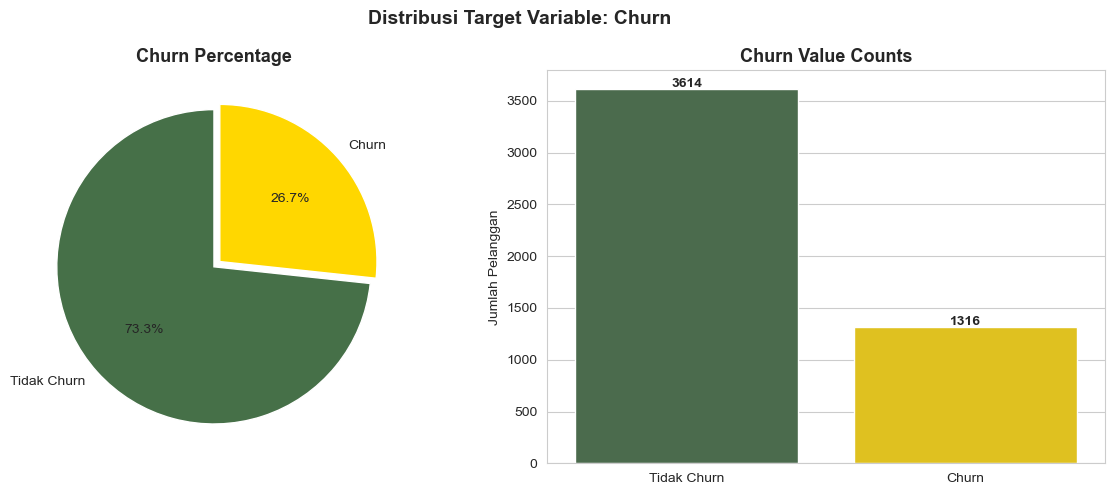

In [5]:
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print('=== Distribusi Target Variable (Churn) ===')
print(f'No  (Tidak Churn) : {churn_counts["No"]:,} pelanggan ({churn_pct["No"]:.1f}%)')
print(f'Yes (Churn)       : {churn_counts["Yes"]:,} pelanggan ({churn_pct["Yes"]:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].pie(churn_counts.values, labels=['Tidak Churn', 'Churn'],
            autopct='%1.1f%%', colors=['#467048', 'gold'],
            explode=(0, 0.05), startangle=90)
axes[0].set_title('Churn Percentage', fontsize=13, fontweight='bold')

sns.barplot(x=['Tidak Churn', 'Churn'], y=churn_counts.values,
            palette=['#467048', 'gold'], ax=axes[1])
for i, v in enumerate(churn_counts.values):
    axes[1].text(i, v + 20, str(v), ha='center', fontweight='bold')
axes[1].set_title('Churn Value Counts', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Jumlah Pelanggan')

plt.suptitle('Distribusi Target Variable: Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

> Dataset mengalami **class imbalance** dengan rasio ~73% : 27%.
> - Class majority : **Not Churn (73.3%)**
> - Class minority : **Churn (26.7%)**
>
> Ketidakseimbangan kelas perlu ditangani dengan teknik **resampling** pada tahap modeling.

**Cek Data Duplikat**

In [6]:
duplicate = df.duplicated().sum()
print(f'Jumlah Data Duplikat: {duplicate}')

Jumlah Data Duplikat: 77


In [7]:
df = df.drop_duplicates()

> Terdapat **77 data duplikat** yang telah dihapus untuk memastikan kualitas data training.

**Cek Missing Values**

In [8]:
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / df.shape[0]) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing (%)': missing_pct.round(2)})
display(missing_df)
print(f'\n✅ Total missing values: {missing.sum()}')

,Missing Count,Missing (%)
Dependents,0,0.0
tenure,0,0.0
OnlineSecurity,0,0.0
OnlineBackup,0,0.0
InternetService,0,0.0
DeviceProtection,0,0.0
TechSupport,0,0.0
Contract,0,0.0
PaperlessBilling,0,0.0
MonthlyCharges,0,0.0



✅ Total missing values: 0


**Cek Outliers**

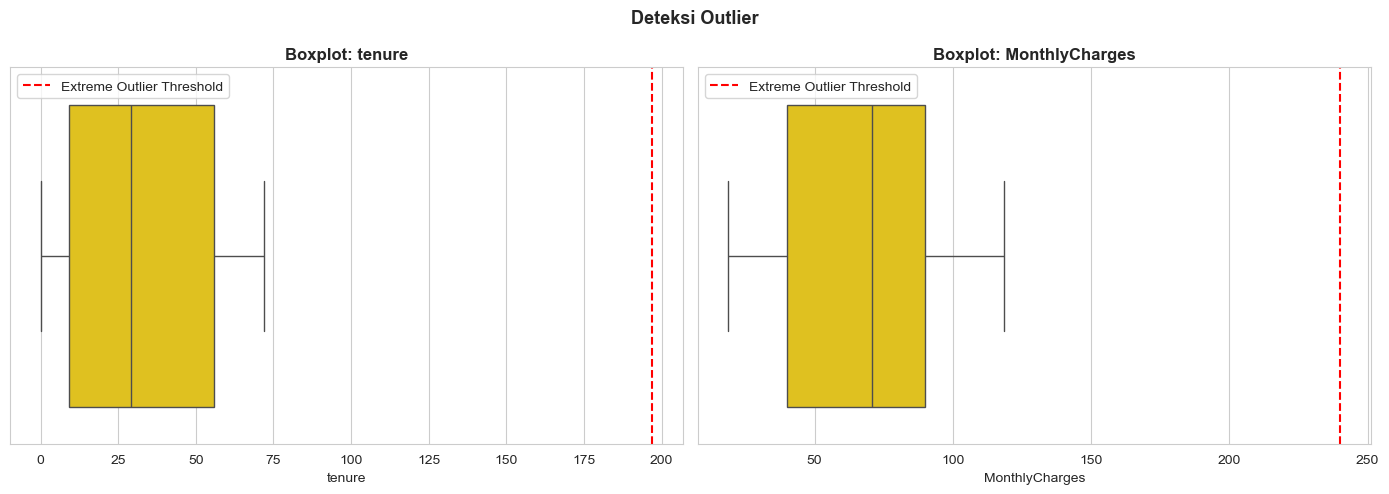

tenure: 0 outlier
MonthlyCharges: 0 outlier


In [9]:
num_cols = ['tenure', 'MonthlyCharges']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for idx, col in enumerate(num_cols):
    extreme_upper = df[col].quantile(0.75) + 3 * (df[col].quantile(0.75) - df[col].quantile(0.25))
    sns.boxplot(x=df[col], color='gold', ax=axes[idx])
    axes[idx].axvline(x=extreme_upper, linestyle='--', color='red', label='Extreme Outlier Threshold')
    axes[idx].set_title(f'Boxplot: {col}', fontweight='bold')
    axes[idx].legend()

plt.suptitle('Deteksi Outlier', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

for col in num_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)][col].count()
    print(f'{col}: {outliers} outlier')

> Tidak terdapat outlier pada kolom numerikal berdasarkan metode IQR.
> Nilai ekstrem yang ada masih masuk akal secara bisnis sehingga **tidak dihapus**.

**Uji Normalitas pada Kolom Numerikal**

In [10]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

normality_results = {}
for col in numerical_cols:
    stat, p = stats.shapiro(df[col].dropna().sample(min(5000, len(df)), random_state=42))
    normality_results[col] = {'Shapiro Stat': round(stat, 4), 'p-value': round(p, 6)}

normality_df = pd.DataFrame(normality_results).T.reset_index()
normality_df.columns = ['Feature', 'Shapiro Stat', 'p-value']
normality_df['Distribusi'] = normality_df['p-value'].apply(
    lambda p: '✅ Normal' if p > 0.05 else '❌ Tidak Normal'
)
normality_df['Scaler Rekomendasi'] = normality_df['p-value'].apply(
    lambda p: 'MinMaxScaler' if p > 0.05 else 'RobustScaler'
)
display(normality_df)

,Feature,Shapiro Stat,p-value,Distribusi,Scaler Rekomendasi
0,tenure,0.9071,0.0,❌ Tidak Normal,RobustScaler
1,MonthlyCharges,0.9245,0.0,❌ Tidak Normal,RobustScaler


> Semua kolom numerikal **tidak terdistribusi normal** (p ≤ 0.05).
> → Akan digunakan **RobustScaler** yang tahan terhadap distribusi skewed.

**Cek Nilai Unik pada Kolom Kategorikal**

In [11]:
categorical_cols_raw = df.select_dtypes(include='object').columns.tolist()
unique_values = {col: df[col].unique() for col in categorical_cols_raw}
df_unique = pd.DataFrame(
    [(col, len(values), sorted(values)) for col, values in unique_values.items()],
    columns=['Kolom', 'Jumlah Nilai Unik', 'Nilai Unik']
)
pd.set_option('display.max_colwidth', None)
display(df_unique)

,Kolom,Jumlah Nilai Unik,Nilai Unik
0,Dependents,2,"[No, Yes]"
1,OnlineSecurity,3,"[No, No internet service, Yes]"
2,OnlineBackup,3,"[No, No internet service, Yes]"
3,InternetService,3,"[DSL, Fiber optic, No]"
4,DeviceProtection,3,"[No, No internet service, Yes]"
5,TechSupport,3,"[No, No internet service, Yes]"
6,Contract,3,"[Month-to-month, One year, Two year]"
7,PaperlessBilling,2,"[No, Yes]"
8,Churn,2,"[No, Yes]"


**Cek Korelasi Features dan Label**

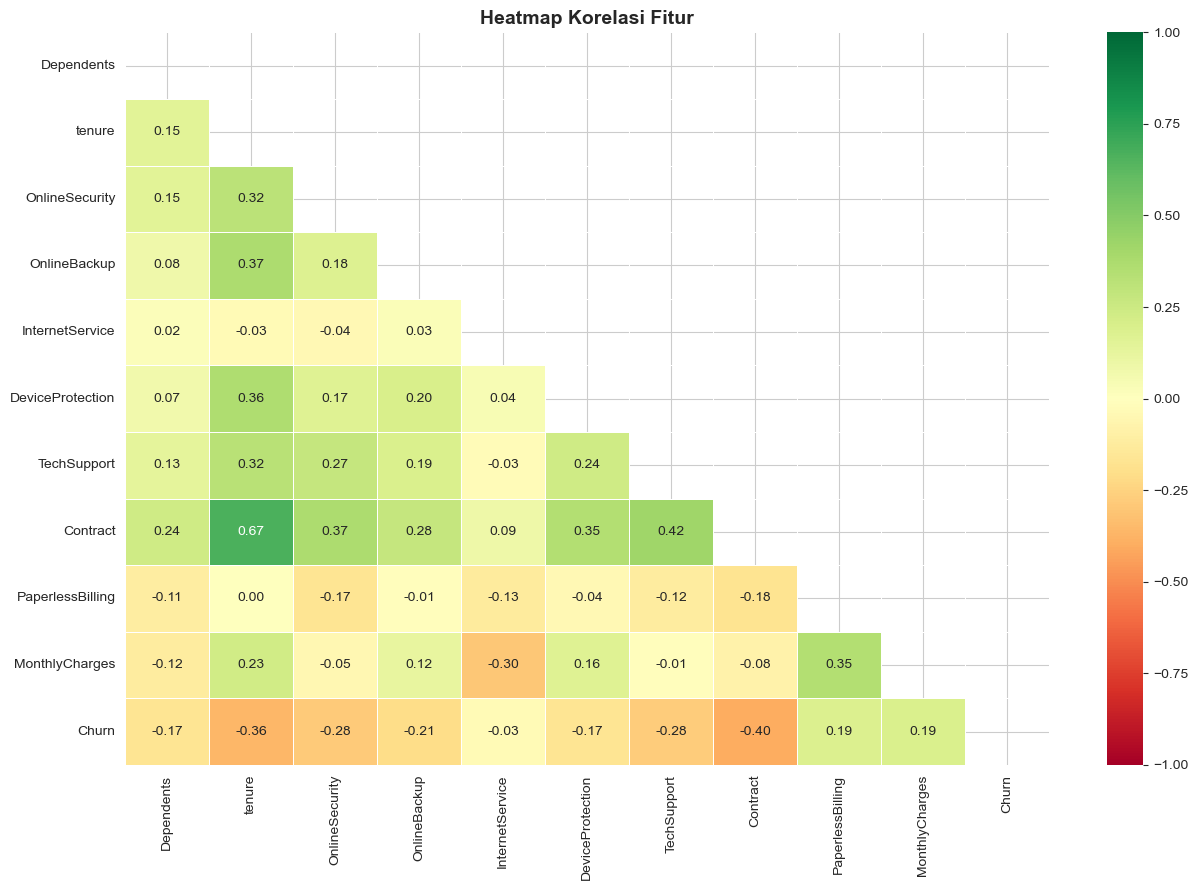


📊 Korelasi Fitur terhadap Target (Churn):
Contract           -0.402
tenure             -0.361
OnlineSecurity     -0.283
TechSupport        -0.276
OnlineBackup       -0.209
MonthlyCharges      0.194
PaperlessBilling    0.186
Dependents         -0.169
DeviceProtection   -0.169
InternetService    -0.033


In [12]:
df_encoded_corr = df.copy()
df_encoded_corr['Churn'] = df_encoded_corr['Churn'].map({'Yes': 1, 'No': 0})
for col in df_encoded_corr.select_dtypes(include='object').columns:
    df_encoded_corr[col] = LabelEncoder().fit_transform(df_encoded_corr[col])

corr_matrix = df_encoded_corr.corr()

plt.figure(figsize=(13, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', fmt='.2f',
            linewidths=0.5, mask=mask, vmin=-1, vmax=1)
plt.title('Heatmap Korelasi Fitur', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

churn_corr = corr_matrix['Churn'].drop('Churn').sort_values(key=abs, ascending=False)
print('\n📊 Korelasi Fitur terhadap Target (Churn):')
print(churn_corr.round(3).to_string())

> - Fitur `Contract` memiliki **korelasi negatif terbesar** terhadap Churn (-0.402) — pelanggan dengan kontrak panjang cenderung tidak churn
> - Fitur `tenure` memiliki korelasi negatif besar (-0.361) — semakin lama berlangganan, semakin kecil kemungkinan churn
> - Fitur `MonthlyCharges` berkorelasi **positif** (0.194) — tagihan tinggi meningkatkan risiko churn

**EDA — Churn Rate berdasarkan Fitur Kategorikal**

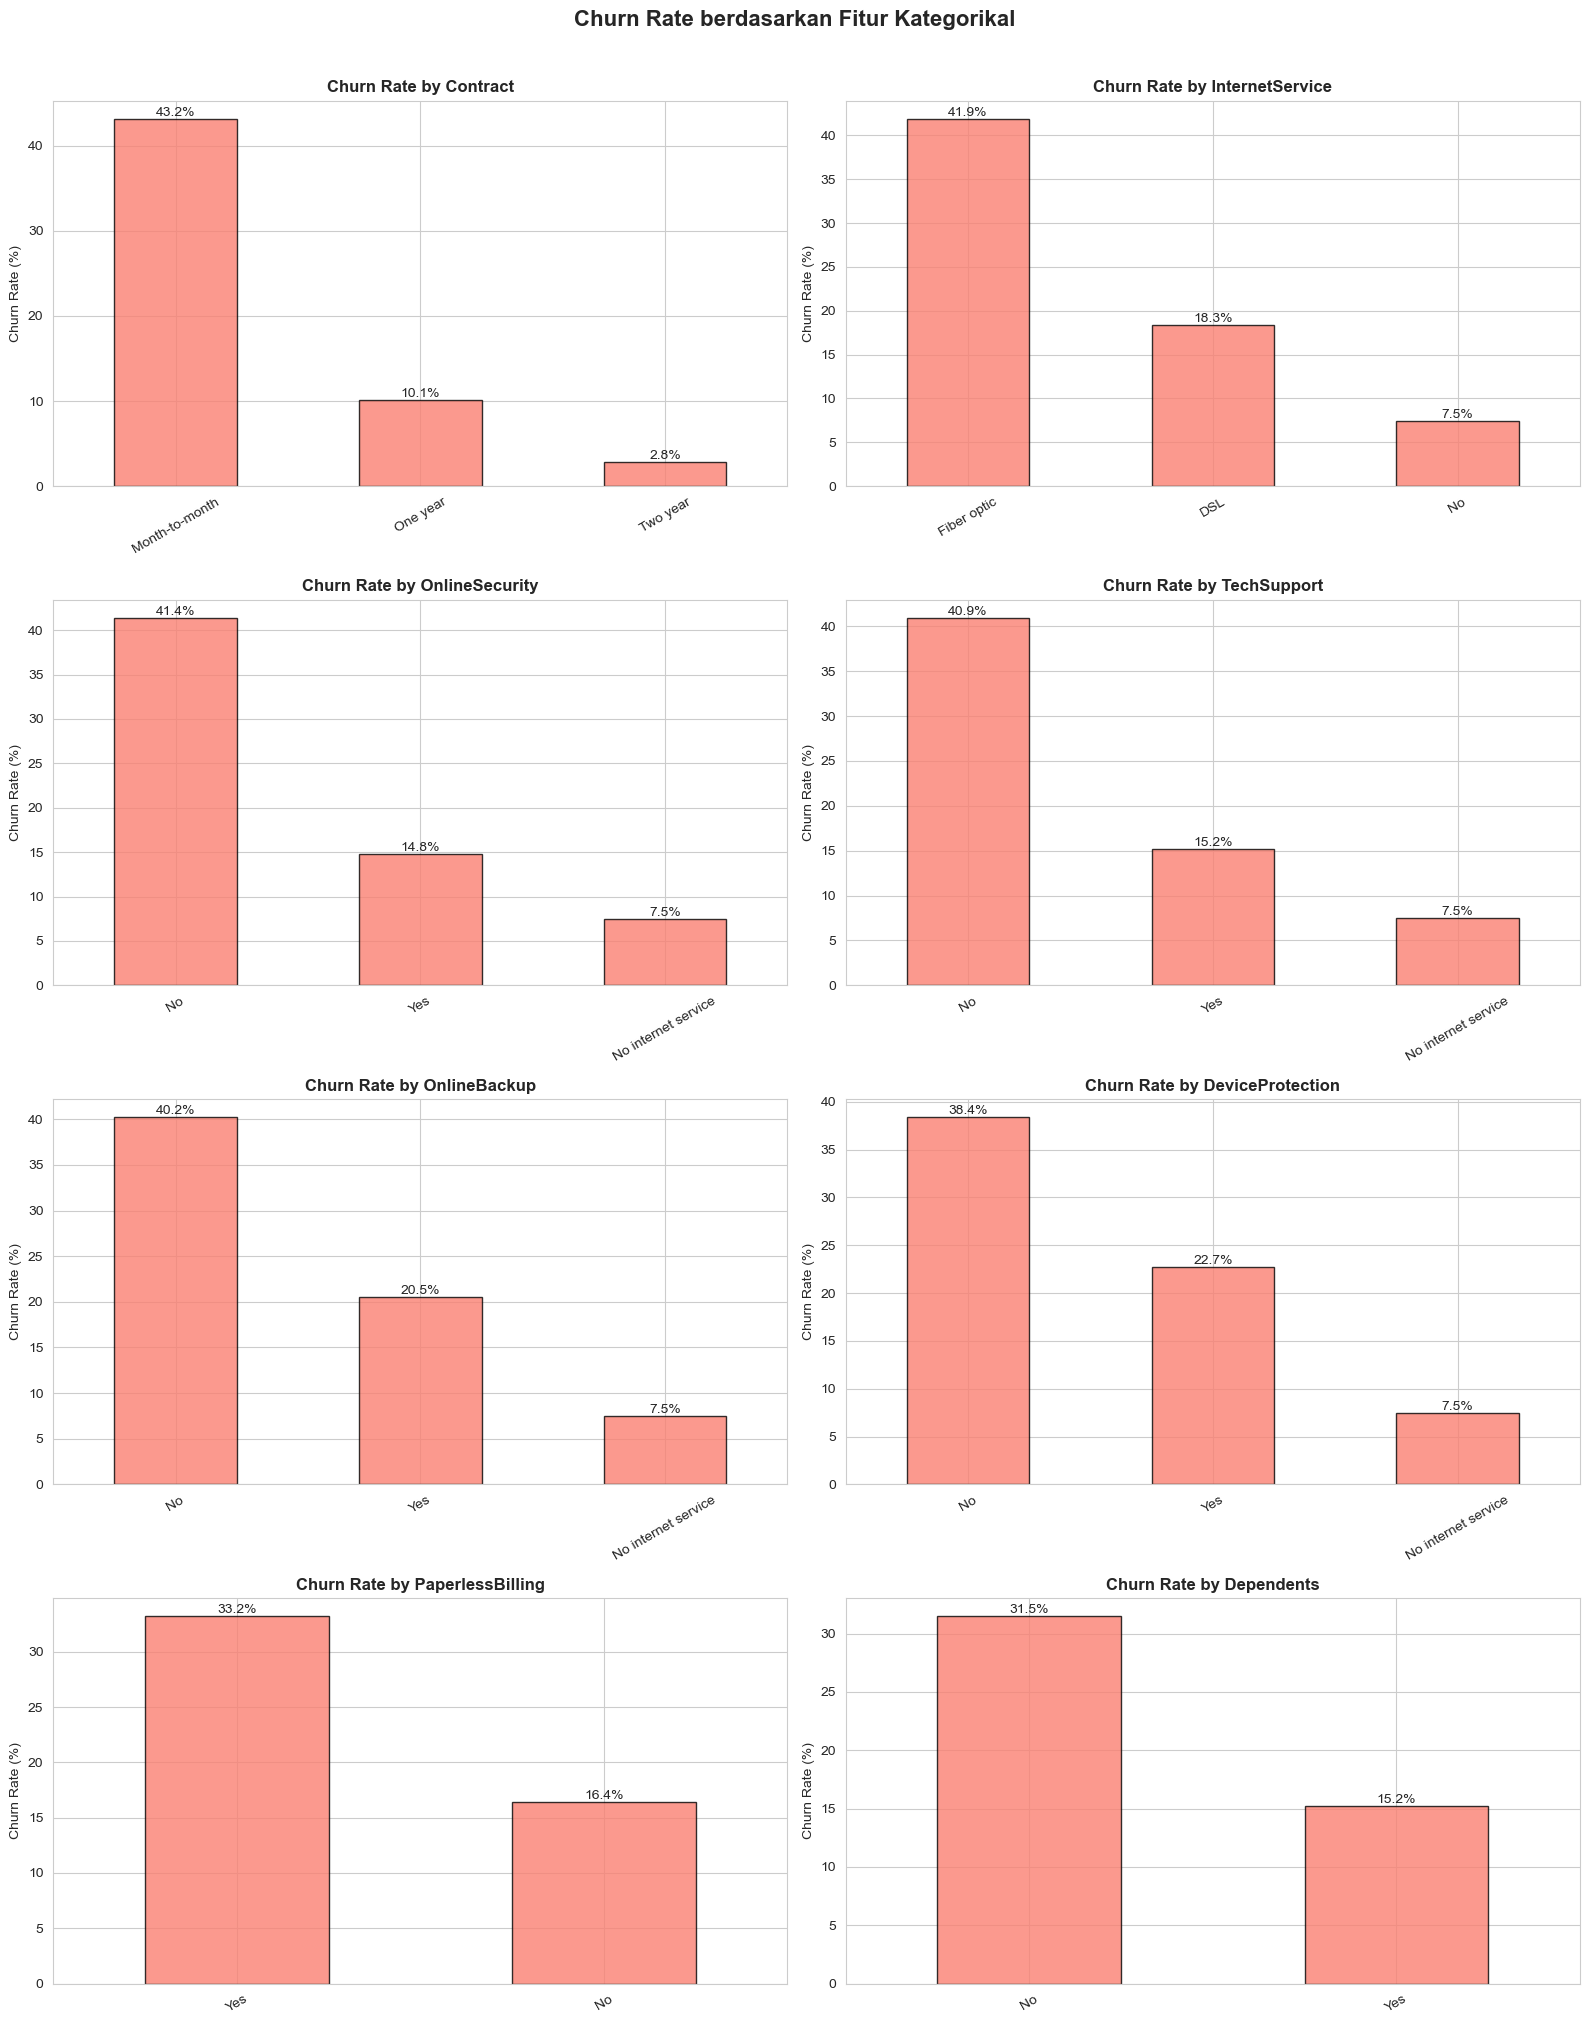

In [13]:
cat_features = ['Contract', 'InternetService', 'OnlineSecurity', 'TechSupport',
                'OnlineBackup', 'DeviceProtection', 'PaperlessBilling', 'Dependents']

fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()

for idx, col in enumerate(cat_features):
    churn_pct_col = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
    churn_pct_col.sort_values(ascending=False).plot(
        kind='bar', ax=axes[idx], color='salmon', edgecolor='black', alpha=0.8)
    axes[idx].set_title(f'Churn Rate by {col}', fontweight='bold')
    axes[idx].set_ylabel('Churn Rate (%)')
    axes[idx].set_xlabel('')
    axes[idx].tick_params(axis='x', rotation=30)
    for p in axes[idx].patches:
        axes[idx].annotate(f'{p.get_height():.1f}%',
                          (p.get_x() + p.get_width()/2, p.get_height()),
                          ha='center', va='bottom', fontsize=10)

plt.suptitle('Churn Rate berdasarkan Fitur Kategorikal', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

> - Pelanggan dengan kontrak **Month-to-month** memiliki churn rate tertinggi (~43%)
> - Pengguna **Fiber optic** lebih rentan churn dibanding DSL
> - Pelanggan **tanpa** OnlineSecurity, TechSupport, dan OnlineBackup cenderung lebih banyak churn

**EDA — Distribusi Fitur Numerik berdasarkan Churn**

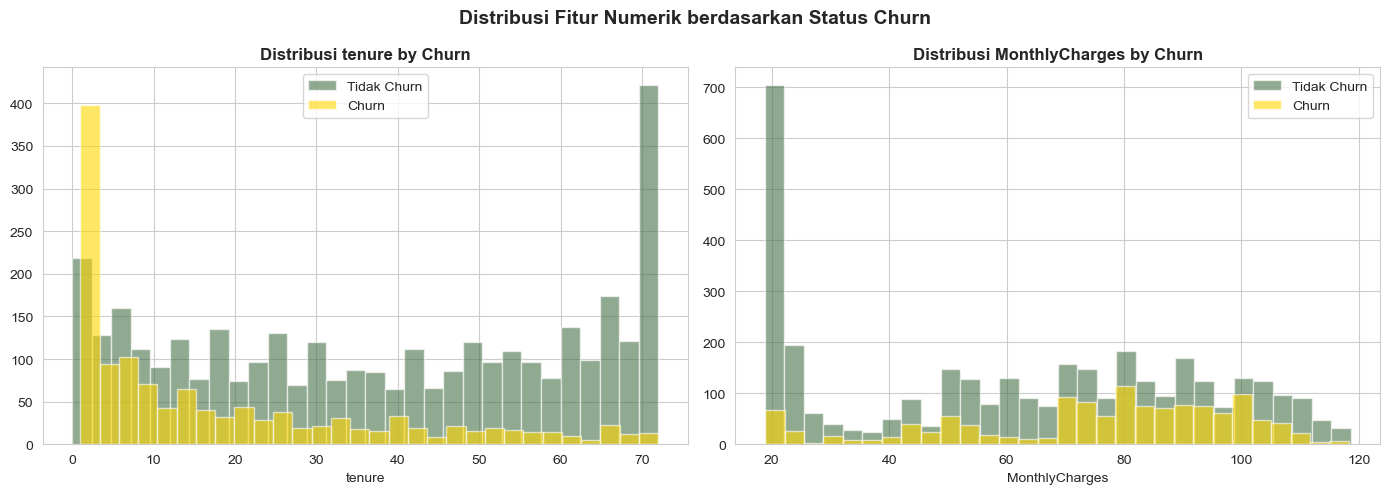

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, col in enumerate(['tenure', 'MonthlyCharges']):
    df[df['Churn']=='No'][col].hist(ax=axes[idx], bins=30, alpha=0.6,
                                     color='#467048', label='Tidak Churn')
    df[df['Churn']=='Yes'][col].hist(ax=axes[idx], bins=30, alpha=0.6,
                                      color='gold', label='Churn')
    axes[idx].set_title(f'Distribusi {col} by Churn', fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].legend()

plt.suptitle('Distribusi Fitur Numerik berdasarkan Status Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

> - Pelanggan dengan **tenure pendek** (0-12 bulan) cenderung lebih banyak churn
> - Pelanggan dengan **MonthlyCharges tinggi** lebih berisiko churn

# 3. Data Preparation

## 3.1. Feature Engineering

> Membuat fitur-fitur baru yang dapat menangkap informasi lebih kompleks dari data yang ada.

In [15]:
df_model = df.copy()
df_model['Churn'] = df_model['Churn'].map({'Yes': 1, 'No': 0})

# Feature 1: Kategori tenure
df_model['tenure_category'] = pd.cut(df_model['tenure'],
                                      bins=[0, 12, 24, 48, 72],
                                      labels=['New (0-12m)', 'Medium (13-24m)',
                                              'Long (25-48m)', 'Loyal (49-72m)'],
                                      include_lowest=True)  # include tenure=0

# Feature 2: Jumlah layanan tambahan
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport']
df_model['total_services'] = df_model[service_cols].apply(
    lambda row: sum(row == 'Yes'), axis=1)

# Feature 3: Indikator penggunaan internet
df_model['has_internet'] = (df_model['InternetService'] != 'No').astype(int)

print('✅ Feature Engineering selesai:')
df_model[['tenure', 'tenure_category', 'total_services', 'has_internet', 'Churn']].head(5)

✅ Feature Engineering selesai:


,tenure,tenure_category,total_services,has_internet,Churn
0,9,New (0-12m),2,1,1
1,14,Medium (13-24m),2,1,0
2,64,Loyal (49-72m),3,1,1
3,72,Loyal (49-72m),4,1,0
4,3,New (0-12m),0,0,0


- **Tenur_category** : Kategori lama berlangganan (New/Medium/Long/Loyal)
- **total_services**: Jumlah layanan tambahan yang dipakai (0-4)
- **has_internet**:  Apakah pelanggan berlangganan internet (0/1)
- Feature engineering berbasis domain knowledge dapat significantly boost model performance

## 3.2. Definisi Label dan Features

In [16]:
categorical_features = [
    'Dependents', 'OnlineSecurity', 'OnlineBackup', 'InternetService',
    'DeviceProtection', 'TechSupport', 'Contract', 'PaperlessBilling',
    'tenure_category'
]
numerical_features_robust = ['tenure', 'MonthlyCharges']
numerical_features_minmax = ['total_services', 'has_internet']

X = df_model[categorical_features + numerical_features_robust + numerical_features_minmax]
y = df_model['Churn']

print(f'Shape X (fitur): {X.shape}')
print(f'Shape y (target): {y.shape}')
print(f'\nDistribusi target:')
print(y.value_counts())

Shape X (fitur): (4853, 13)
Shape y (target): (4853,)

Distribusi target:
Churn
0    3565
1    1288
Name: count, dtype: int64


## 3.3. Split Data Train dan Test

Split Data Train dan Test adalah proses membagi dataset menjadi dua bagian utama dan  dilakukan menggunakan `stratify=y` untuk menjaga proporsi kelas pada data train dan test:
- **Train Data (Data Latih)** – Digunakan untuk melatih model agar memahami pola dalam data. Model belajar dari data ini untuk menyesuaikan bobot dan parameter.
- **Test Data (Data Uji)** – Digunakan untuk mengevaluasi performa model setelah dilatih. Data ini tidak pernah digunakan selama pelatihan, sehingga hasil evaluasi bisa mencerminkan bagaimana model akan bekerja pada data baru yang belum pernah dilihat.

In [17]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Ukuran Training set: {X_train_raw.shape[0]} baris ({X_train_raw.shape[0]/len(X)*100:.1f}%)')
print(f'Ukuran Testing set : {X_test_raw.shape[0]} baris ({X_test_raw.shape[0]/len(X)*100:.1f}%)')
print(f'\nDistribusi Churn di Training set:')
print(y_train.value_counts(normalize=True).round(3))
print(f'\nDistribusi Churn di Testing set:')
print(y_test.value_counts(normalize=True).round(3))
print('\n✅ Proporsi kelas terjaga dengan baik (stratify berhasil)')

Ukuran Training set: 3882 baris (80.0%)
Ukuran Testing set : 971 baris (20.0%)

Distribusi Churn di Training set:
Churn
0    0.735
1    0.265
Name: proportion, dtype: float64

Distribusi Churn di Testing set:
Churn
0    0.734
1    0.266
Name: proportion, dtype: float64

✅ Proporsi kelas terjaga dengan baik (stratify berhasil)


## 3.4. Data Preprocessing

> Berdasarkan hasil eksplorasi, preprocessing dilakukan sebagai berikut:
> - `tenure`, `MonthlyCharges` → **RobustScaler** (distribusi tidak normal, tahan skewed)
> - `total_services`, `has_internet` → **MinMaxScaler** (sudah binary/count kecil)
> - Fitur kategorikal → **OneHotEncoder**
>
> Preprocessing dilakukan **setelah split** untuk mencegah data leakage.

In [18]:
preprocessor = ColumnTransformer([
    ('Numerical_Robust', Pipeline([('Scaler', RobustScaler())]), numerical_features_robust),
    ('Numerical_MinMax', Pipeline([('Scaler', MinMaxScaler())]), numerical_features_minmax),
    ('Categorical', Pipeline([('Encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), categorical_features)
])

X_train_preprocessed = preprocessor.fit_transform(X_train_raw)
X_test_preprocessed  = preprocessor.transform(X_test_raw)

feature_names = preprocessor.get_feature_names_out()
feature_names = [n.replace('Numerical_Robust__', '').replace('Numerical_MinMax__', '').replace('Categorical__', '')
                 for n in feature_names]

X_train = pd.DataFrame(X_train_preprocessed, columns=feature_names, index=y_train.index)
X_test  = pd.DataFrame(X_test_preprocessed,  columns=feature_names, index=y_test.index)

print(f'Shape X_train setelah preprocessing: {X_train.shape}')
print(f'Shape X_test  setelah preprocessing: {X_test.shape}')
print('\nSample X_train:')
display(X_train.head(3))

Shape X_train setelah preprocessing: (3882, 30)
Shape X_test  setelah preprocessing: (971, 30)

Sample X_train:


,tenure,MonthlyCharges,total_services,has_internet,Dependents_No,Dependents_Yes,OnlineSecurity_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No,OnlineBackup_No internet service,OnlineBackup_Yes,InternetService_DSL,InternetService_Fiber optic,InternetService_No,DeviceProtection_No,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No,TechSupport_No internet service,TechSupport_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,tenure_category_Long (25-48m),tenure_category_Loyal (49-72m),tenure_category_Medium (13-24m),tenure_category_New (0-12m)
4072,-0.489362,-0.303912,0.5,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4512,0.361702,0.647944,0.5,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
3970,0.553191,-1.014042,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0


> X_train dan X_test telah berhasil di-preprocess dan siap digunakan untuk modeling.

# 4. Modeling

## 4.1. Mencari Model Terbaik

> Saya akan mencari model klasifikasi dengan **F2-Score terbaik** sebagai model baseline.
> Model dikombinasikan dengan beberapa metode resampling dan feature selection.
> Hasil F2-score dari tiap kombinasi diurutkan dan kombinasi terbaik dipilih untuk tuning.

**Resampling untuk Imbalanced Data**

In [19]:
resampling_methods = {
    'None': None,
    'SMOTE': SMOTE(sampling_strategy=0.5, random_state=42),
    'Undersampling': RandomUnderSampler(sampling_strategy=0.5, random_state=42)
}
print('Resampling methods:', list(resampling_methods.keys()))

Resampling methods: ['None', 'SMOTE', 'Undersampling']


> Karena dataset mengalami class imbalance (~73%:27%), tiga metode akan diuji:
> - **None**: Tidak ada resampling
> - **SMOTE**: Oversampling kelas minoritas dengan data sintetis
> - **Undersampling**: Mengurangi kelas mayoritas secara acak

**Feature Selection**

> Feature Selection adalah proses memilih fitur (variabel) yang paling relevan untuk meningkatkan kinerja model machine learning. Tujuannya adalah mengurangi fitur yang tidak penting atau berlebihan, sehingga model menjadi lebih akurat, cepat, dan interpretable.
> Saya akan mengiterasi beberapa teknik feature selection untuk menemukan apakah model akan lebih baik apabila memakai fitur dengan jumlah tertentu.

In [20]:
feature_selectors = {
    'None': None,
    'SelectKBest (k=10)': SelectKBest(f_classif, k=10),
    'SelectKBest (k=15)': SelectKBest(f_classif, k=15),
}
print('Feature selection methods:', list(feature_selectors.keys()))

Feature selection methods: ['None', 'SelectKBest (k=10)', 'SelectKBest (k=15)']


**Definisi Model-model Klasifikasi**

In [21]:
def get_models():
    return {
        'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
        'Decision Tree'       : DecisionTreeClassifier(random_state=42),
        'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42),
        'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=100, random_state=42),
        'XGBoost'             : XGBClassifier(n_estimators=100, eval_metric='logloss', random_state=42, verbosity=0),
        'LightGBM'            : lgb.LGBMClassifier(n_estimators=100, random_state=42, verbose=-1),
        'Extra Trees'         : ExtraTreesClassifier(n_estimators=100, random_state=42),
        'CatBoost'            : CatBoostClassifier(n_estimators=100, random_state=42, verbose=0),
        'Bagging'             : BaggingClassifier(n_estimators=100, random_state=42),
    }

print(f'Total model: {len(get_models())}')
for name in get_models():
    print(f'  - {name}')

Total model: 9
  - Logistic Regression
  - Decision Tree
  - Random Forest
  - Gradient Boosting
  - XGBoost
  - LightGBM
  - Extra Trees
  - CatBoost
  - Bagging


**Mencari Model Benchmark**

> Model Benchmark adalah model referensi yang digunakan sebagai tolak ukur untuk mengevaluasi kinerja model yang sedang dikembangkan.
> Dengan adanya benchmark, kita dapat menentukan apakah model baru memberikan hasil yang lebih baik dibandingkan dengan pendekatan sederhana atau model sebelumnya.

In [22]:
benchmark_results = []
total_combos = len(resampling_methods) * len(feature_selectors) * len(get_models())
print(f'Total kombinasi: {total_combos}')

for resample_name, resample_method in resampling_methods.items():
    if resample_method:
        X_resampled, y_resampled = clone(resample_method).fit_resample(X_train, y_train)
    else:
        X_resampled, y_resampled = X_train.copy(), y_train.copy()

    for fs_name, fs_method in feature_selectors.items():
        fs = clone(fs_method) if fs_method else None
        if fs:
            X_res_sel  = fs.fit_transform(X_resampled, y_resampled)
            X_test_sel = fs.transform(X_test)
        else:
            X_res_sel  = X_resampled
            X_test_sel = X_test

        for model_name, model in get_models().items():
            model.fit(X_res_sel, y_resampled)
            y_pred = model.predict(X_test_sel)
            benchmark_results.append({
                'Model'            : model_name,
                'Resampling'       : resample_name,
                'Feature Selection': fs_name,
                'F2 Score'         : round(fbeta_score(y_test, y_pred, beta=2), 6),
                'Recall'           : round(recall_score(y_test, y_pred), 4),
                'Precision'        : round(precision_score(y_test, y_pred, zero_division=0), 4),
            })

benchmark_df = pd.DataFrame(benchmark_results).sort_values('F2 Score', ascending=False).reset_index(drop=True)

display(benchmark_df.head(15))

Total kombinasi: 81


  File "c:\Users\tryou\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\tryou\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\tryou\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\tryou\anaconda3\Lib\subprocess.

,Model,Resampling,Feature Selection,F2 Score,Recall,Precision
0,Logistic Regression,SMOTE,None,0.636992,0.6434,0.6125
1,Logistic Regression,SMOTE,SelectKBest (k=10),0.626424,0.6395,0.5789
2,Logistic Regression,SMOTE,SelectKBest (k=15),0.624524,0.6357,0.5836
3,Logistic Regression,Undersampling,None,0.622598,0.6279,0.6022
4,Logistic Regression,Undersampling,SelectKBest (k=10),0.622598,0.6279,0.6022
5,Gradient Boosting,Undersampling,SelectKBest (k=15),0.622155,0.6357,0.5734
6,Gradient Boosting,Undersampling,None,0.616808,0.6202,0.6038
7,Gradient Boosting,Undersampling,SelectKBest (k=10),0.615970,0.6279,0.5724
8,Logistic Regression,Undersampling,SelectKBest (k=15),0.614912,0.6202,0.5948
9,CatBoost,SMOTE,SelectKBest (k=10),0.613027,0.6202,0.5861


> Berdasarkan hasil evaluasi terhadap berbagai model dengan metode resampling dan seleksi fitur yang berbeda, model Logistic Regression dengan SMOTE tanpa feature selection menunjukkan performa terbaik dengan nilai F2-score tertinggi.
>
> SMOTE (Synthetic Minority Over-sampling Technique) digunakan untuk meningkatkan jumlah sampel kelas minoritas, sehingga model dapat belajar dengan lebih baik tanpa bias terhadap kelas mayoritas.
>
> Ketika seleksi fitur diterapkan, performa model sedikit menurun, hal ini menunjukkan bahwa semua fitur yang tersedia memiliki kontribusi yang berarti, sehingga tidak perlu dilakukan penghapusan fitur.


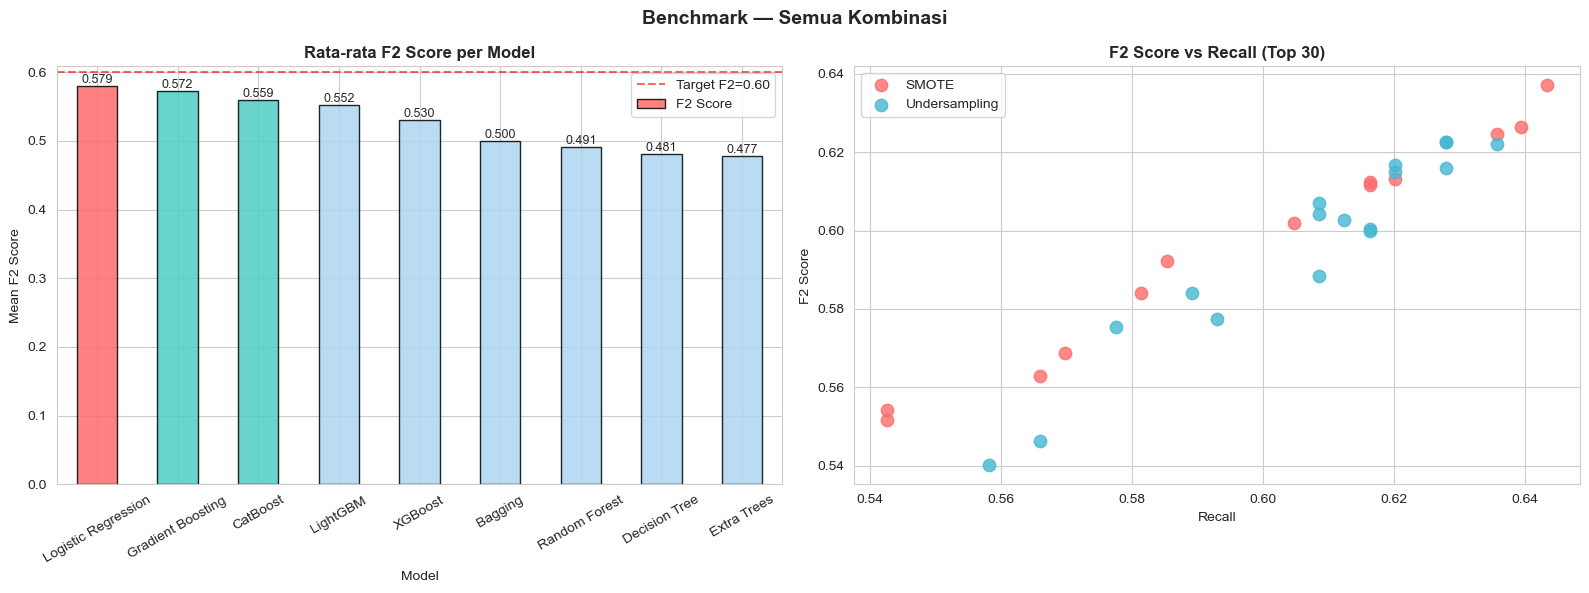

In [23]:
# Visualisasi rata-rata F2 per model
avg_f2_per_model = benchmark_df.groupby('Model')['F2 Score'].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors_bar = ['#FF6B6B' if i == 0 else '#4ECDC4' if i <= 2 else '#AED6F1'
              for i in range(len(avg_f2_per_model))]
avg_f2_per_model.plot(kind='bar', ax=axes[0], color=colors_bar, edgecolor='black', alpha=0.85)
axes[0].set_title('Rata-rata F2 Score per Model', fontweight='bold')
axes[0].set_ylabel('Mean F2 Score')
axes[0].tick_params(axis='x', rotation=30)
axes[0].axhline(y=0.60, color='red', linestyle='--', alpha=0.6, label='Target F2=0.60')
axes[0].legend()
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.3f}',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=9)

top30 = benchmark_df.head(30)
scatter_colors = {'None': '#4ECDC4', 'SMOTE': '#FF6B6B', 'Undersampling': '#45B7D1'}
for resample_name, group in top30.groupby('Resampling'):
    axes[1].scatter(group['Recall'], group['F2 Score'], label=f'{resample_name}',
                    color=scatter_colors.get(resample_name, 'gray'), alpha=0.8, s=80)
axes[1].set_title('F2 Score vs Recall (Top 30)', fontweight='bold')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('F2 Score')
axes[1].legend()

plt.suptitle('Benchmark — Semua Kombinasi', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

> **Insight**

> - **Logistic Regression memiliki F2 tertinggi (0.625)** dibanding model boosting lainnya.
> - **SMOTE cenderung menghasilkan F2 dan recall lebih tinggi** dibanding undersampling.
> - Secara efisiensi dan interpretasi, **Logistic Regression + SMOTE menjadi kombinasi paling rasional**.

In [24]:
best_row = benchmark_df.iloc[0]
best_model_name    = best_row['Model']
best_resample_name = best_row['Resampling']
best_fs_name       = best_row['Feature Selection']

print('=' * 55)
print('   KOMBINASI TERBAIK DARI BENCHMARK')
print('=' * 55)
print(f'  Model            : {best_model_name}')
print(f'  Resampling       : {best_resample_name}')
print(f'  Feature Selection: {best_fs_name}')
print(f'  F2 Score         : {best_row["F2 Score"]:.4f}')
print(f'  Recall           : {best_row["Recall"]:.4f}')
print(f'  Precision        : {best_row["Precision"]:.4f}')

model_classes = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'       : DecisionTreeClassifier(random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=100, random_state=42),
    'XGBoost'             : XGBClassifier(n_estimators=100, eval_metric='logloss', random_state=42, verbosity=0),
    'LightGBM'            : lgb.LGBMClassifier(n_estimators=100, random_state=42, verbose=-1),
    'Extra Trees'         : ExtraTreesClassifier(n_estimators=100, random_state=42),
    'CatBoost'            : CatBoostClassifier(n_estimators=100, random_state=42, verbose=0),
    'Bagging'             : BaggingClassifier(n_estimators=100, random_state=42),
}

best_resample = resampling_methods[best_resample_name]
if best_resample:
    X_res_best, y_res_best = clone(best_resample).fit_resample(X_train, y_train)
else:
    X_res_best, y_res_best = X_train.copy(), y_train.copy()

best_fs = feature_selectors[best_fs_name]
if best_fs:
    fs_best = clone(best_fs)
    X_res_best_sel  = fs_best.fit_transform(X_res_best, y_res_best)
    X_test_best_sel = fs_best.transform(X_test)
    X_train_best_sel = fs_best.transform(X_train)
else:
    X_res_best_sel  = X_res_best
    X_test_best_sel = X_test
    X_train_best_sel = X_train

baseline_model = clone(model_classes[best_model_name])
baseline_model.fit(X_res_best_sel, y_res_best)
y_train_pred_before = baseline_model.predict(X_train_best_sel)
y_test_pred_before  = baseline_model.predict(X_test_best_sel)
train_f2_before = fbeta_score(y_train, y_train_pred_before, beta=2)
test_f2_before  = fbeta_score(y_test,  y_test_pred_before,  beta=2)

print(f'\n=== Performa Baseline ({best_model_name}) Sebelum Tuning ===')
print(f'  F2-Score (Train): {train_f2_before:.4f}')
print(f'  F2-Score (Test) : {test_f2_before:.4f}')
print(classification_report(y_test, y_test_pred_before, target_names=['Tidak Churn', 'Churn']))

   KOMBINASI TERBAIK DARI BENCHMARK
  Model            : Logistic Regression
  Resampling       : SMOTE
  Feature Selection: None
  F2 Score         : 0.6370
  Recall           : 0.6434
  Precision        : 0.6125

=== Performa Baseline (Logistic Regression) Sebelum Tuning ===
  F2-Score (Train): 0.6287
  F2-Score (Test) : 0.6370
              precision    recall  f1-score   support

 Tidak Churn       0.87      0.85      0.86       713
       Churn       0.61      0.64      0.63       258

    accuracy                           0.80       971
   macro avg       0.74      0.75      0.74       971
weighted avg       0.80      0.80      0.80       971



**Confusion Matrix Sebelum Tuning**

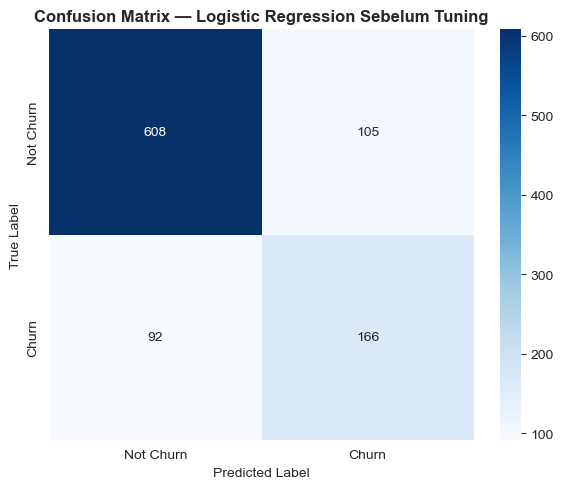

In [25]:
cm_before = confusion_matrix(y_test, y_test_pred_before)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_before, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Churn', 'Churn'], yticklabels=['Not Churn', 'Churn'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Confusion Matrix — {best_model_name} Sebelum Tuning', fontweight='bold')
plt.tight_layout()
plt.show()

> **Insight**
> - Model **tidak mengalami overfitting**, karena F2-score train (0.6287) dan test (0.6370) sangat berdekatan. Ini menunjukkan model mampu melakukan generalisasi dengan baik dan tidak hanya menghafal data training.
> - Performa pada kelas churn cukup stabil dengan recall sebesar **0.64**, artinya model mampu mendeteksi 64% pelanggan yang benar-benar churn.
> - Meskipun demikian, masih terdapat **92 false negative**, sehingga ada pelanggan churn yang belum teridentifikasi.
> - Secara keseluruhan, model sudah cukup seimbang, namun peningkatan sebaiknya difokuskan pada peningkatan recall kelas churn untuk meminimalkan risiko kehilangan pelanggan.

## 4.2. Hyperparameter Tuning Menggunakan GridSearchCV

> Karena model terbaik telah ditemukan, langkah selanjutnya adalah optimasi hyperparameter menggunakan **GridSearchCV** untuk mendapatkan konfigurasi parameter yang optimal dan mengurangi overfitting.

In [26]:
param_grids = {
    'Logistic Regression': {
        'classifier__C': [0.01, 0.1, 1, 10],
        'classifier__penalty': ['l1', 'l2'],
        'classifier__solver': ['liblinear', 'saga']
    },
    'Decision Tree': {
        'classifier__max_depth': [3, 5, 7, None],
        'classifier__min_samples_split': [2, 5, 10],
        'classifier__min_samples_leaf': [1, 2, 4]
    },
    'Random Forest': {
        'classifier__n_estimators': [100, 200],
        'classifier__max_depth': [3, 5, 7],
        'classifier__min_samples_split': [2, 5],
        'classifier__max_features': ['sqrt', 'log2']
    },
    'Gradient Boosting': {
        'classifier__n_estimators': [100, 200],
        'classifier__max_depth': [2, 3, 4],
        'classifier__learning_rate': [0.05, 0.1],
        'classifier__subsample': [0.8, 1.0]
    },
    'XGBoost': {
        'classifier__n_estimators': [100, 200],
        'classifier__max_depth': [3, 4, 5],
        'classifier__learning_rate': [0.05, 0.1],
        'classifier__subsample': [0.8, 1.0],
        'classifier__colsample_bytree': [0.6, 0.8],
        'classifier__reg_alpha': [0, 0.5, 1],
        'classifier__reg_lambda': [1, 2],
    },
    'LightGBM': {
        'classifier__n_estimators': [100, 200],
        'classifier__max_depth': [3, 5, 7],
        'classifier__learning_rate': [0.05, 0.1],
        'classifier__num_leaves': [15, 31],
        'classifier__reg_alpha': [0, 0.5],
        'classifier__reg_lambda': [0, 1],
    },
    'Extra Trees': {
        'classifier__n_estimators': [100, 200],
        'classifier__max_depth': [3, 5, 7, None],
        'classifier__min_samples_split': [2, 5],
        'classifier__max_features': ['sqrt', 'log2']
    },
    'CatBoost': {
        'classifier__iterations': [100, 200],
        'classifier__depth': [4, 6, 8],
        'classifier__learning_rate': [0.05, 0.1],
        'classifier__l2_leaf_reg': [1, 3, 5],
    },
    'Bagging': {
        'classifier__n_estimators': [50, 100, 200],
        'classifier__max_samples': [0.7, 1.0],
        'classifier__max_features': [0.7, 1.0],
    },
}

steps = []
if best_resample_name != 'None':
    steps.append(('resampling', clone(resampling_methods[best_resample_name])))
if best_fs_name != 'None':
    steps.append(('feature_selection', clone(feature_selectors[best_fs_name])))
steps.append(('classifier', clone(model_classes[best_model_name])))

pipeline = ImbPipeline(steps)
param_grid = param_grids[best_model_name]

print(f'Model : {best_model_name}')
print(f'Resampling : {best_resample_name}')
print(f'Pipeline steps: {[s[0] for s in steps]}')

Model : Logistic Regression
Resampling : SMOTE
Pipeline steps: ['resampling', 'classifier']


In [27]:
f2_scorer = make_scorer(fbeta_score, beta=2)

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring=f2_scorer,
    cv=5,
    verbose=1,
    n_jobs=-1,
    return_train_score=True
)
grid_search.fit(X_train, y_train)

print(f'Best Parameters: {grid_search.best_params_}')
print(f'Best CV F2-Score: {grid_search.best_score_:.4f}')

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Parameters: {'classifier__C': 10, 'classifier__penalty': 'l1', 'classifier__solver': 'saga'}
Best CV F2-Score: 0.6209


## 4.3. Evaluasi Model

**Perbandingan Sebelum vs Sesudah Tuning**

In [28]:
cv_results_df = pd.DataFrame(grid_search.cv_results_)
param_cols  = [col for col in cv_results_df.columns if col.startswith('param_')]
metric_cols = ['mean_test_score', 'std_test_score', 'mean_fit_time']
grid_results_display = cv_results_df[param_cols + metric_cols].rename(columns={
    'mean_test_score': 'Mean F2-Score',
    'std_test_score' : 'F2-Score Std',
    'mean_fit_time'  : 'Fit Time (s)'
}).sort_values('Mean F2-Score', ascending=False)
display(grid_results_display.head(10))

best_pipeline = grid_search.best_estimator_
y_train_pred_after = best_pipeline.predict(X_train)
y_test_pred_after  = best_pipeline.predict(X_test)
train_f2_after = fbeta_score(y_train, y_train_pred_after, beta=2)
test_f2_after  = fbeta_score(y_test,  y_test_pred_after,  beta=2)

print('\n=== Perbandingan Sebelum vs Sesudah Tuning ===')
print(f'{"Metrik":<25} {"Sebelum":>10} {"Sesudah":>10} {"Delta":>10}')
print('-' * 55)
print(f'{"F2-Score (Train)":<25} {train_f2_before:>10.4f} {train_f2_after:>10.4f} {train_f2_after-train_f2_before:>+10.4f}')
print(f'{"F2-Score (Test)":<25} {test_f2_before:>10.4f} {test_f2_after:>10.4f} {test_f2_after-test_f2_before:>+10.4f}')

,param_classifier__C,param_classifier__penalty,param_classifier__solver,Mean F2-Score,F2-Score Std,Fit Time (s)
13,10.0,l1,saga,0.620886,0.032747,0.398076
12,10.0,l1,liblinear,0.620771,0.032863,0.234372
11,1.0,l2,saga,0.620365,0.033603,0.342330
14,10.0,l2,liblinear,0.620037,0.032716,0.038649
15,10.0,l2,saga,0.620037,0.032716,0.644357
8,1.0,l1,liblinear,0.619692,0.031907,0.053504
9,1.0,l1,saga,0.619661,0.032256,0.128587
10,1.0,l2,liblinear,0.619544,0.032605,0.048922
4,0.1,l1,liblinear,0.618643,0.035444,0.052952
6,0.1,l2,liblinear,0.616451,0.039216,0.046179



=== Perbandingan Sebelum vs Sesudah Tuning ===
Metrik                       Sebelum    Sesudah      Delta
-------------------------------------------------------
F2-Score (Train)              0.6287     0.6329    +0.0042
F2-Score (Test)               0.6370     0.6403    +0.0033


> **Insight Perbandingan Sebelum vs Sesudah Tuning**
> - Terjadi peningkatan F2-score setelah tuning, namun sangat kecil (Train +0.0042 dan Test +0.0033).
> - Kenaikan ini tidak signifikan secara praktis dan belum memberikan improvement yang berarti terhadap performa model.
> - Hal ini menunjukkan bahwa hyperparameter tuning tidak banyak mengubah kemampuan generalisasi model.
> - Oleh karena itu, akan dilakukan **threshold optimization**, karena penyesuaian threshold lebih relevan untuk meningkatkan F2-score yang berfokus pada recall dan meminimalkan false negative.

**Threshold Optimization**

> Threshold default (0.5) tidak optimal untuk kasus imbalanced. Threshold yang lebih rendah akan meningkatkan Recall sesuai prioritas bisnis.

,F2 Score,Recall,Precision,F1-Score,Accuracy
Threshold,,,,,
0.15,0.7443,0.9186,0.4232,0.5795,0.6457
0.20,0.7474,0.8992,0.4462,0.5964,0.6766
0.22,0.7468,0.8915,0.4528,0.6005,0.6849
0.25,0.7568,0.8876,0.4761,0.6198,0.7106
0.28,0.7471,0.8566,0.4944,0.6270,0.7291
0.30,0.7442,0.8411,0.5094,0.6345,0.7425
0.35,0.7113,0.7791,0.5276,0.6291,0.7559
0.40,0.7024,0.7519,0.5559,0.6392,0.7745
0.45,0.6798,0.7093,0.5828,0.6399,0.7878



 Threshold terpilih : 0.25
 F2 Score terbaik   : 0.7568


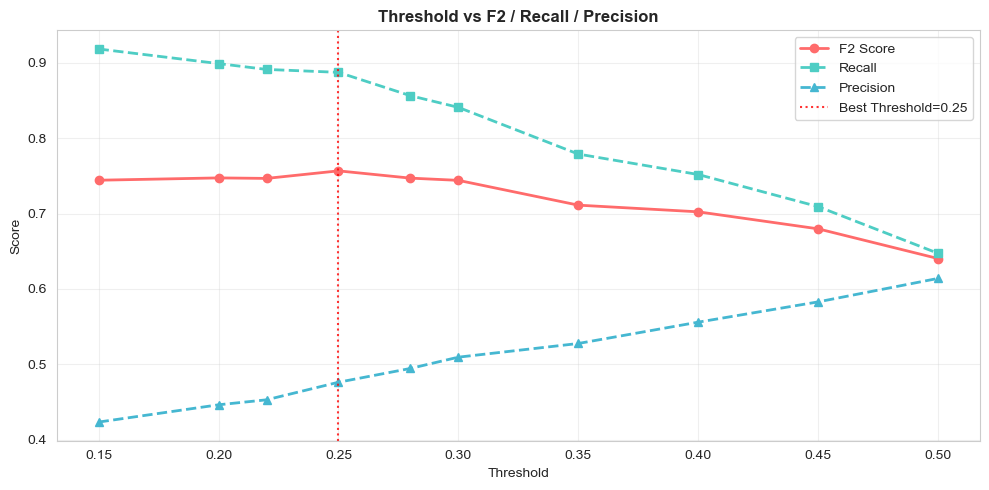

In [29]:
y_prob_test  = grid_search.predict_proba(X_test)[:, 1]
y_prob_train = grid_search.predict_proba(X_train)[:, 1]

thresholds = [0.15, 0.20, 0.22, 0.25, 0.28, 0.30, 0.35, 0.40, 0.45, 0.50]
threshold_results = []
for thresh in thresholds:
    y_pred_thresh = (y_prob_test >= thresh).astype(int)
    threshold_results.append({
        'Threshold'  : thresh,
        'F2 Score': fbeta_score(y_test, y_pred_thresh, beta=2),
        'Recall'     : recall_score(y_test, y_pred_thresh),
        'Precision'  : precision_score(y_test, y_pred_thresh, zero_division=0),
        'F1-Score'   : f1_score(y_test, y_pred_thresh),
        'Accuracy'   : accuracy_score(y_test, y_pred_thresh)
    })

thresh_df = pd.DataFrame(threshold_results).set_index('Threshold')
display(thresh_df.round(4))

BEST_THRESHOLD = thresh_df['F2 Score'].idxmax()
best_f2_thresh = thresh_df['F2 Score'].max()
print(f'\n Threshold terpilih : {BEST_THRESHOLD}')
print(f' F2 Score terbaik   : {best_f2_thresh:.4f}')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresh_df.index, thresh_df['F2 Score'], 'o-', color='#FF6B6B', lw=2, label='F2 Score')
ax.plot(thresh_df.index, thresh_df['Recall'],     's--', color='#4ECDC4', lw=2, label='Recall')
ax.plot(thresh_df.index, thresh_df['Precision'],  '^--', color='#45B7D1', lw=2, label='Precision')
ax.axvline(x=BEST_THRESHOLD, color='red', linestyle=':', alpha=0.8, label=f'Best Threshold={BEST_THRESHOLD}')
ax.set_title('Threshold vs F2 / Recall / Precision', fontweight='bold')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

> **Insight Threshold Optimization**
> - F2-score tertinggi diperoleh pada **threshold 0.25 (0.7568)**, meningkat signifikan dibanding default 0.50 (0.6403).
> - Penurunan threshold meningkatkan **recall secara drastis** (hingga 0.8876–0.9186), yang berarti lebih banyak pelanggan churn berhasil terdeteksi.
> - Namun, semakin rendah threshold, **precision menurun**, sehingga false positive meningkat.
> - Default threshold 0.50 menghasilkan accuracy tertinggi (0.7981), tetapi recall jauh lebih rendah (0.6473).
> - Mengingat fokus bisnis adalah meminimalkan pelanggan churn yang terlewat (false negative), **threshold 0.25 menjadi pilihan paling optimal** karena memberikan keseimbangan terbaik sesuai objektif F2-score.

**Classification Report**

In [30]:
y_pred_final = (y_prob_test >= BEST_THRESHOLD).astype(int)
P  = precision_score(y_test, y_pred_final, zero_division=0)
R  = recall_score(y_test, y_pred_final)
F2 = fbeta_score(y_test, y_pred_final, beta=2)

print('=' * 60)
print(f'     EVALUASI FINAL MODEL — {best_model_name}')
print(f'     Threshold: {BEST_THRESHOLD}')
print('=' * 60)
print(f'\n   F2 Score  : {F2:.4f}  ← (Target: ≥0.70)')
print(f'   Recall    : {R:.4f}')
print(f'   Precision : {P:.4f}')
print(f'   ROC-AUC   : {roc_auc_score(y_test, y_prob_test):.4f}')
print(f'   Accuracy  : {accuracy_score(y_test, y_pred_final):.4f}')
print()
print(classification_report(y_test, y_pred_final, target_names=['Tidak Churn (0)', 'Churn (1)']))

     EVALUASI FINAL MODEL — Logistic Regression
     Threshold: 0.25

   F2 Score  : 0.7568  ← (Target: ≥0.70)
   Recall    : 0.8876
   Precision : 0.4761
   ROC-AUC   : 0.8446
   Accuracy  : 0.7106

                 precision    recall  f1-score   support

Tidak Churn (0)       0.94      0.65      0.77       713
      Churn (1)       0.48      0.89      0.62       258

       accuracy                           0.71       971
      macro avg       0.71      0.77      0.69       971
   weighted avg       0.82      0.71      0.73       971



**Confusion Matrix**

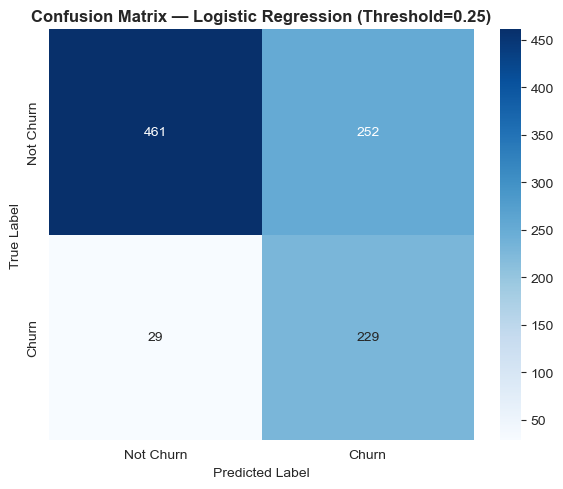

In [31]:
cm_final = confusion_matrix(y_test, y_pred_final)
TN, FP, FN, TP = cm_final.ravel()

plt.figure(figsize=(6, 5))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Churn', 'Churn'], yticklabels=['Not Churn', 'Churn'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Confusion Matrix — {best_model_name} (Threshold={BEST_THRESHOLD})', fontweight='bold')
plt.tight_layout()
plt.show()

> **Insight**
> - True Positive  (TP): 229 — churn berhasil dideteksi
> - True Negative  (TN): 461 — tidak churn, benar diprediksi
> - False Positive (FP): 252 — tidak churn tapi diprediksi churn
> - False Negative (FN): 29 — churn tidak terdeteksi (PALING MAHAL)

**ROC dan AUC**

ROC-AUC adalah metrik penting untuk mengevaluasi performa model klasifikasi dalam menyeimbangkan True Positive Rate dan False Positive Rate.

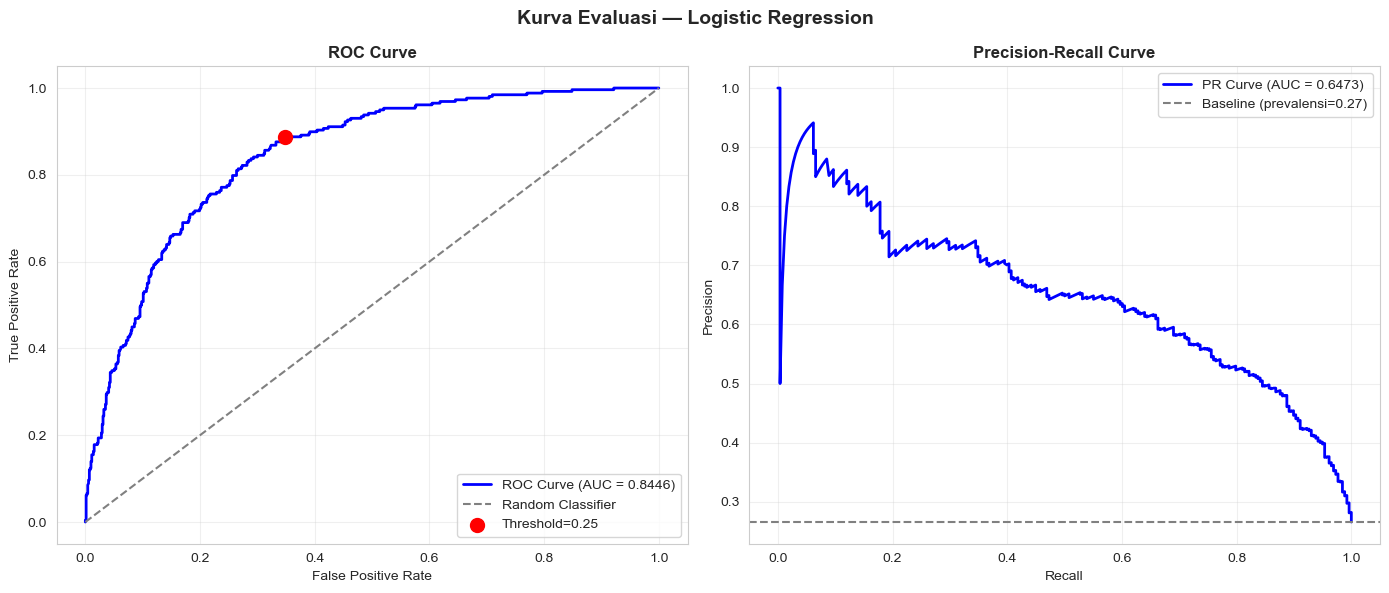

ROC-AUC: 0.8446 | PR-AUC: 0.6473


In [32]:
fpr, tpr, thresholds_roc = roc_curve(y_test, y_prob_test)
roc_auc = roc_auc_score(y_test, y_prob_test)
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_prob_test)
pr_auc = auc(recall_vals, precision_vals)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
axes[0].plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')
thresh_idx = np.argmin(np.abs(thresholds_roc - BEST_THRESHOLD))
axes[0].scatter(fpr[thresh_idx], tpr[thresh_idx], color='red', s=100, zorder=5,
                label=f'Threshold={BEST_THRESHOLD}')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve', fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

axes[1].plot(recall_vals, precision_vals, color='blue', lw=2, label=f'PR Curve (AUC = {pr_auc:.4f})')
axes[1].axhline(y=y_test.mean(), color='gray', linestyle='--',
                label=f'Baseline (prevalensi={y_test.mean():.2f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve', fontweight='bold')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Kurva Evaluasi — {best_model_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'ROC-AUC: {roc_auc:.4f} | PR-AUC: {pr_auc:.4f}')

> **Insight**
> - Model memperoleh **ROC-AUC sebesar 0.8446**, menunjukkan kemampuan yang kuat dalam membedakan pelanggan churn dan non-churn secara probabilistik.
> - **PR-AUC sebesar 0.6473** tergolong cukup solid untuk kasus imbalance seperti churn, di mana metrik precision-recall lebih relevan.
> - Hasil ini mengindikasikan bahwa model memiliki kualitas probabilitas yang baik, sehingga threshold optimization menjadi efektif untuk meningkatkan F2-score sesuai objektif bisnis.

## 4.4. Feature Importance

**Barplot**

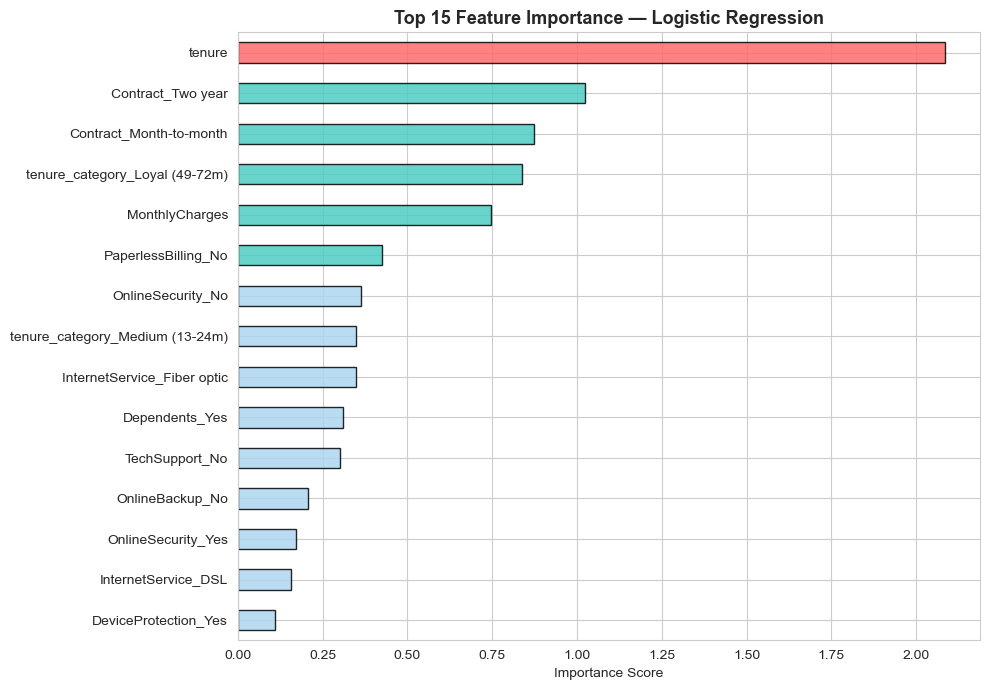

In [33]:
final_model_for_fi = clone(model_classes[best_model_name])
best_params_clean = {k.replace('classifier__', ''): v
                     for k, v in grid_search.best_params_.items()
                     if k.startswith('classifier__')}
final_model_for_fi.set_params(**best_params_clean)

if best_resample_name != 'None':
    X_res_fi, y_res_fi = clone(resampling_methods[best_resample_name]).fit_resample(X_train, y_train)
else:
    X_res_fi, y_res_fi = X_train.copy(), y_train.copy()

if best_fs_name != 'None':
    fs_fi = clone(feature_selectors[best_fs_name])
    X_res_fi = fs_fi.fit_transform(X_res_fi, y_res_fi)
    fi_columns = [X_train.columns[i] for i in fs_fi.get_support(indices=True)]
else:
    fi_columns = list(X_train.columns)

final_model_for_fi.fit(X_res_fi, y_res_fi)

if hasattr(final_model_for_fi, 'feature_importances_'):
    feat_imp = pd.Series(final_model_for_fi.feature_importances_, index=fi_columns)
elif hasattr(final_model_for_fi, 'coef_'):
    feat_imp = pd.Series(abs(final_model_for_fi.coef_[0]), index=fi_columns)
else:
    feat_imp = None

if feat_imp is not None:
    top15 = feat_imp.sort_values(ascending=False).head(15)
    colors = ['#FF6B6B' if v > top15.max()*0.5 else
              '#4ECDC4' if v > top15.max()*0.2 else '#AED6F1'
              for v in top15.sort_values().values]
    plt.figure(figsize=(10, 7))
    top15.sort_values().plot(kind='barh', color=colors, edgecolor='black', alpha=0.85)
    plt.title(f'Top 15 Feature Importance — {best_model_name}', fontsize=13, fontweight='bold')
    plt.xlabel('Importance Score')
    plt.tight_layout()
    plt.show()

> **Insight Top 5 Fitur Paling Berpengaruh**
> - `tenure` : Fitur dengan pengaruh terbesar dalam memprediksi churn. Lama berlangganan menjadi indikator utama, di mana pelanggan dengan masa berlangganan lebih panjang cenderung lebih stabil dan memiliki risiko churn yang berbeda dibanding pelanggan baru.
> - `Contract_Two year` : Kontrak dua tahun berpengaruh kuat dalam menurunkan kemungkinan churn, karena pelanggan terikat dalam periode yang lebih panjang.
> - `Contract_Month-to-month` : Kontrak bulanan meningkatkan risiko churn, karena pelanggan memiliki fleksibilitas untuk berhenti kapan saja.
> - `tenure_category_Loyal (49-72m)` : Kategori pelanggan loyal menunjukkan pengaruh signifikan, mengindikasikan bahwa segmentasi berdasarkan lama berlangganan membantu model menangkap pola churn dengan lebih jelas.
> - `MonthlyCharges` : Besarnya biaya bulanan turut memengaruhi keputusan churn, di mana biaya yang lebih tinggi dapat meningkatkan sensitivitas pelanggan terhadap harga.

**SHAP**

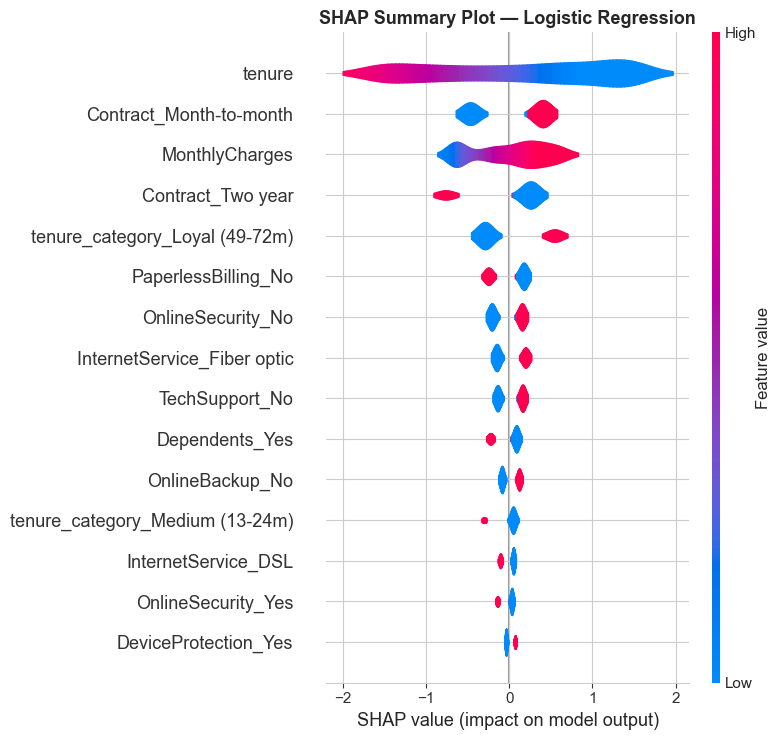


Top 10 Fitur berdasarkan SHAP:


,Feature,Mean |SHAP Value|
0,tenure,0.951817
21,Contract_Month-to-month,0.433326
1,MonthlyCharges,0.386013
23,Contract_Two year,0.384789
27,tenure_category_Loyal (49-72m),0.372129
24,PaperlessBilling_No,0.203812
6,OnlineSecurity_No,0.182185
13,InternetService_Fiber optic,0.170643
18,TechSupport_No,0.150681
5,Dependents_Yes,0.126625


In [34]:
# Initialize SHAP explainer with the trained model
explainer = shap.Explainer(final_model_for_fi, X_test)
shap_vals = explainer(X_test)
shap_matrix = shap_vals.values

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_vals, X_test, feature_names=list(X_test.columns),
                plot_type='violin', show=False, max_display=15)
plt.title(f'SHAP Summary Plot — {best_model_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

shap_importance = pd.DataFrame({
    'Feature': X_test.columns,
    'Mean |SHAP Value|': np.abs(shap_matrix).mean(axis=0)
}).sort_values('Mean |SHAP Value|', ascending=False)

print('\nTop 10 Fitur berdasarkan SHAP:')
display(shap_importance.head(10))

> **Insight SHAP Feature Importance**
> - `tenure` memiliki dampak paling besar terhadap prediksi churn. Nilai SHAP tertinggi menunjukkan bahwa lama berlangganan adalah faktor utama, di mana pelanggan baru cenderung meningkatkan risiko churn, sedangkan pelanggan lama lebih stabil.
> - `Contract_Month-to-month` berpengaruh signifikan terhadap churn. Pelanggan dengan kontrak bulanan memiliki kemungkinan churn lebih tinggi karena tidak terikat komitmen jangka panjang.
> - `MonthlyCharges` menunjukkan bahwa besarnya biaya bulanan memengaruhi keputusan pelanggan. Semakin tinggi biaya, semakin sensitif pelanggan terhadap kemungkinan berhenti berlangganan.
> - `Contract_Two year` berkontribusi dalam menurunkan risiko churn, menandakan bahwa kontrak jangka panjang memberikan efek retensi yang kuat.
> - `tenure_category_Loyal (49-72m)` memperkuat temuan bahwa segmentasi pelanggan berdasarkan durasi berlangganan membantu model dalam mengidentifikasi kelompok dengan risiko churn lebih rendah.
> - `PaperlessBilling_No`, `OnlineSecurity_No`, `InternetService_Fiber optic`, dan `TechSupport_No` menunjukkan bahwa faktor layanan tambahan dan jenis layanan internet turut memengaruhi churn, terutama ketika pelanggan tidak menggunakan layanan pendukung tertentu.
> - `Dependents_Yes` memiliki pengaruh moderat, mengindikasikan bahwa pelanggan dengan tanggungan cenderung memiliki perilaku churn yang berbeda dibandingkan yang tidak memiliki tanggungan.

## 4.5. Keterbatasan Model

In [35]:
X_test_df = X_test.copy()
X_test_df['Actual_Churn']    = y_test.values
X_test_df['Predicted_Churn'] = y_pred_final
X_test_df['tenure_raw']      = X_test_raw['tenure'].values
X_test_df['tenure_group'] = pd.cut(X_test_df['tenure_raw'],
                                    bins=[0, 12, 24, 48, 72],
                                    labels=['0-12m', '13-24m', '25-48m', '49-72m'])

tenure_perf = X_test_df.groupby('tenure_group').apply(
    lambda g: pd.Series({
        'Count'             : len(g),
        'Actual Churn Rate' : g['Actual_Churn'].mean().round(3),
        'Recall'            : recall_score(g['Actual_Churn'], g['Predicted_Churn']) if g['Actual_Churn'].sum() > 0 else 0,
        'Precision'         : precision_score(g['Actual_Churn'], g['Predicted_Churn'], zero_division=0),
        'F2 Score'          : fbeta_score(g['Actual_Churn'], g['Predicted_Churn'], beta=2)
    })
).round(3)
print('=== Performa Model per Kelompok Tenure ===')
display(tenure_perf)

=== Performa Model per Kelompok Tenure ===


,Count,Actual Churn Rate,Recall,Precision,F2 Score
tenure_group,,,,,
0-12m,272.0,0.474,0.969,0.539,0.836
13-24m,166.0,0.277,0.935,0.439,0.762
25-48m,228.0,0.250,0.807,0.447,0.695
49-72m,304.0,0.086,0.577,0.312,0.493


> Karena model dilatih dengan data historikal, model memiliki keterbatasan berikut:
> - **Performa terbaik** pada pelanggan tenure 0-12 bulan (paling banyak churn)
> - **Performa menurun** pada pelanggan loyal (tenure > 48 bulan) karena data lebih sedikit
> - Model perlu **di-retrain** secara berkala setiap 3-6 bulan
> - Tidak cocok jika ada perubahan besar pada paket layanan atau struktur harga

### Save Best Model ke Pickle

In [36]:
import pickle, json

with open('best_pipeline.pkl', 'wb') as f:
    pickle.dump(grid_search.best_estimator_, f)
with open('preprocessor.pkl', 'wb') as f:
    pickle.dump(preprocessor, f)

model_metadata = {
    'best_model_name'      : best_model_name,
    'best_resample'        : best_resample_name,
    'best_fs'              : best_fs_name,
    'best_threshold'       : BEST_THRESHOLD,
    'best_params'          : best_params_clean,
    'f2_score_test'        : round(F2, 4),
    'recall_test'          : round(R, 4),
    'precision_test'       : round(P, 4),
    'feature_names'        : list(X_train.columns),
    'categorical_features' : categorical_features,
    'numerical_robust'     : numerical_features_robust,
    'numerical_minmax'     : numerical_features_minmax,
}
with open('model_metadata.json', 'w') as f:
    json.dump(model_metadata, f, indent=2)

print('✅ Model berhasil disimpan:')
print('   - best_pipeline.pkl')
print('   - preprocessor.pkl')
print('   - model_metadata.json')

✅ Model berhasil disimpan:
   - best_pipeline.pkl
   - preprocessor.pkl
   - model_metadata.json


# 5. Kesimpulan dan Rekomendasi

## 5.1. Bandingkan Rule-Based vs Machine Learning

Saya akan menghitung total biaya kerugian bisnis untuk membandingkan apakah menggunakan Machine Learning lebih menguntungkan dibanding pendekatan Rule-Based.

**Rule-Based Churn Prediction (Tanpa Machine Learning)**

Pada metode rule-based, digunakan fitur `Contract`, `tenure`, dan `InternetService` sebagai indikator churn.

Pelanggan dianggap churn jika memenuhi setidaknya salah satu kondisi berikut:
- Kontrak **Month-to-month** (tidak ada komitmen jangka panjang)
- **Tenure < 12 bulan** (pelanggan baru, belum terikat)
- **InternetService = Fiber optic** (layanan mahal, lebih rentan pindah)

=== Rule-Based Classification Report ===
              precision    recall  f1-score   support

 Tidak Churn       0.95      0.41      0.57       713
       Churn       0.37      0.95      0.53       258

    accuracy                           0.55       971
   macro avg       0.66      0.68      0.55       971
weighted avg       0.80      0.55      0.56       971

Rule-Based F2 Score : 0.7189
Rule-Based Recall   : 0.9457
Rule-Based Precision: 0.3669


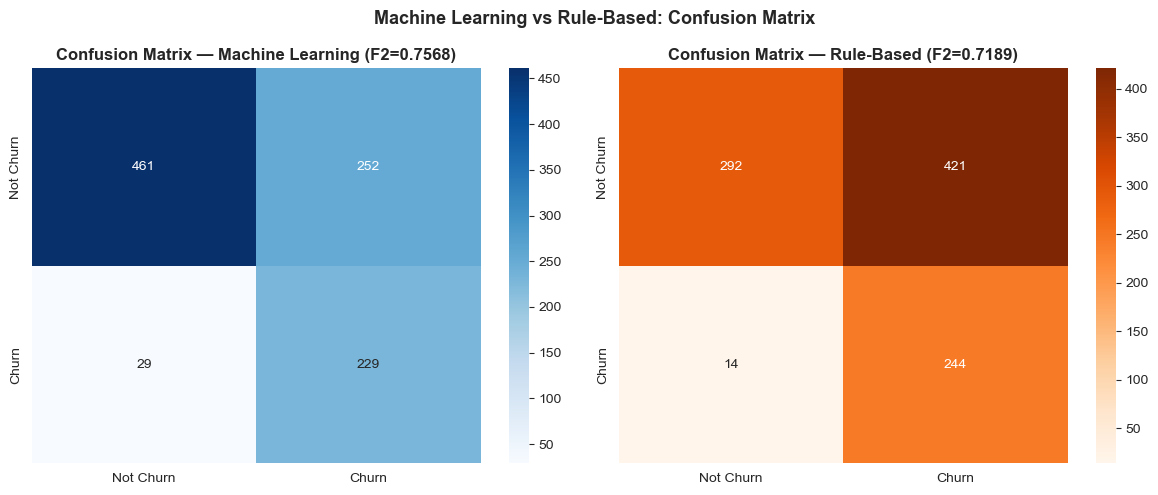

In [37]:
X_rule = X_test_raw.copy()
X_rule['Actual_Churn'] = y_test.values

X_rule['Churn_RuleBased'] = (
    (X_rule['Contract'] == 'Month-to-month') |
    (X_rule['tenure']   < 12) |
    (X_rule['InternetService'] == 'Fiber optic')
).astype(int)

print('=== Rule-Based Classification Report ===')
print(classification_report(X_rule['Actual_Churn'], X_rule['Churn_RuleBased'],
                             target_names=['Tidak Churn', 'Churn']))

f2_rule    = fbeta_score(X_rule['Actual_Churn'], X_rule['Churn_RuleBased'], beta=2)
recall_rule = recall_score(X_rule['Actual_Churn'], X_rule['Churn_RuleBased'])
prec_rule   = precision_score(X_rule['Actual_Churn'], X_rule['Churn_RuleBased'], zero_division=0)

print(f'Rule-Based F2 Score : {f2_rule:.4f}')
print(f'Rule-Based Recall   : {recall_rule:.4f}')
print(f'Rule-Based Precision: {prec_rule:.4f}')

cm_rule = confusion_matrix(X_rule['Actual_Churn'], X_rule['Churn_RuleBased'])
cm_ml   = confusion_matrix(y_test, y_pred_final)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm_ml, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Churn', 'Churn'], yticklabels=['Not Churn', 'Churn'], ax=axes[0])
axes[0].set_title(f'Confusion Matrix — Machine Learning (F2={F2:.4f})', fontweight='bold')

sns.heatmap(cm_rule, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Not Churn', 'Churn'], yticklabels=['Not Churn', 'Churn'], ax=axes[1])
axes[1].set_title(f'Confusion Matrix — Rule-Based (F2={f2_rule:.4f})', fontweight='bold')

plt.suptitle('Machine Learning vs Rule-Based: Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Menurut [Harvard Business Review](https://hbr.org/2014/10/the-value-of-keeping-the-right-customers), biaya untuk mempertahankan pelanggan jauh lebih rendah dibandingkan akuisisi pelanggan baru. Mendapatkan pelanggan baru bisa **5 hingga 25 kali lebih mahal** dibandingkan mempertahankan yang sudah ada.

**Simulasi Perbandingan Kerugian: Rule-Based vs Machine Learning (USD)**

Dari confusion matrix yang diperoleh, total kerugian bisnis dihitung berdasarkan asumsi:
- **Biaya retensi per pelanggan** = $100 *(mencakup biaya call center + voucher diskon)*
- **Revenue hilang per pelanggan churn** (CLV) = $780 *(rata-rata $65/bulan × 12 bulan)*

Definisi kerugian:
- **False Positive (FP)**: Pelanggan yang diprediksi churn tapi tidak — biaya retensi terbuang
  - Formula: `FP × Biaya Retensi`
- **False Negative (FN)**: Pelanggan yang churn tapi tidak terdeteksi — kehilangan revenue
  - Formula: `FN × CLV`

Rata-rata MonthlyCharges: $65.32
CLV per pelanggan: $783.86
=== Simulasi Total Kerugian Bisnis ===

Machine Learning:
  FP = 252 | FN = 29
  Biaya FP (salah prediksi churn) : 252 × $100 = $25,200
  Revenue hilang (FN tidak terdeteksi) : 29 × $784 = $22,732
  ➤ TOTAL KERUGIAN ML              = $47,932

Rule-Based:
  FP = 421 | FN = 14
  Biaya FP (salah prediksi churn) : 421 × $100 = $42,100
  Revenue hilang (FN tidak terdeteksi) : 14 × $784 = $10,974
  ➤ TOTAL KERUGIAN Rule-Based      = $53,074

💰 HEMAT dengan Machine Learning : $5,142 (9.7% lebih efisien)


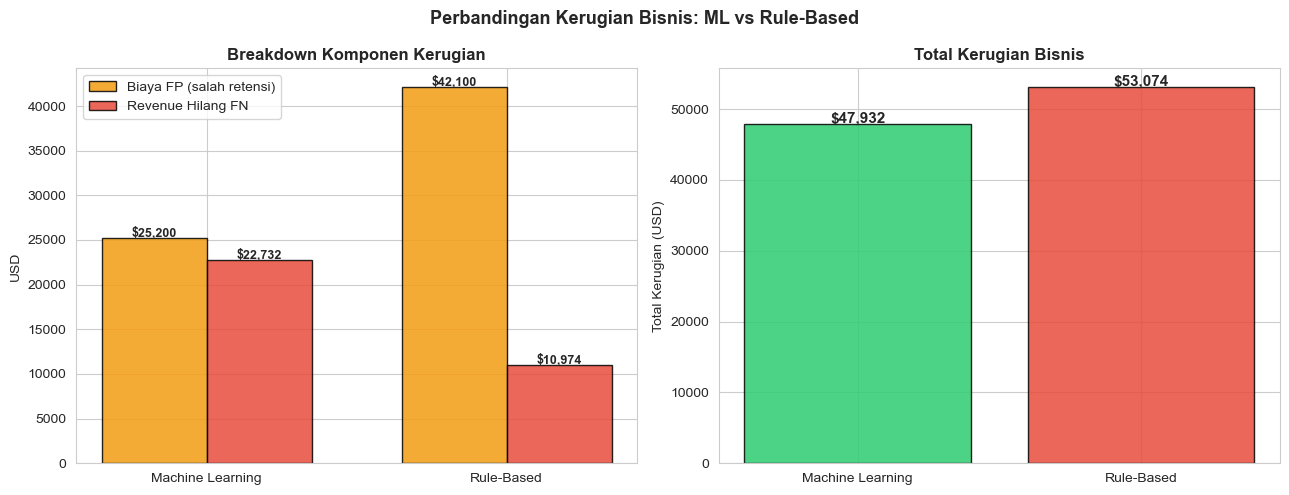

In [38]:
TN_ml, FP_ml, FN_ml, TP_ml = cm_ml.ravel()
TN_rb, FP_rb, FN_rb, TP_rb = cm_rule.ravel()

avg_monthly_revenue = df["MonthlyCharges"].mean()
biaya_retensi = 100   # USD per pelanggan yang dihubungi
clv           = avg_monthly_revenue * 12  # CLV = avg monthly × 12 bulan
print(f"Rata-rata MonthlyCharges: ${avg_monthly_revenue:.2f}")
print(f"CLV per pelanggan: ${clv:.2f}")

# Total Kerugian = FP × biaya_retensi + FN × CLV
loss_ml   = FP_ml * biaya_retensi + FN_ml * clv
loss_rb   = FP_rb * biaya_retensi + FN_rb * clv

print('=== Simulasi Total Kerugian Bisnis ===')
print()
print('Machine Learning:')
print(f'  FP = {FP_ml} | FN = {FN_ml}')
print(f'  Biaya FP (salah prediksi churn) : {FP_ml} × ${biaya_retensi:,} = ${FP_ml * biaya_retensi:,.0f}')
print(f'  Revenue hilang (FN tidak terdeteksi) : {FN_ml} × ${clv:,.0f} = ${FN_ml * clv:,.0f}')
print(f'  ➤ TOTAL KERUGIAN ML              = ${loss_ml:,.0f}')
print()
print('Rule-Based:')
print(f'  FP = {FP_rb} | FN = {FN_rb}')
print(f'  Biaya FP (salah prediksi churn) : {FP_rb} × ${biaya_retensi:,} = ${FP_rb * biaya_retensi:,.0f}')
print(f'  Revenue hilang (FN tidak terdeteksi) : {FN_rb} × ${clv:,.0f} = ${FN_rb * clv:,.0f}')
print(f'  ➤ TOTAL KERUGIAN Rule-Based      = ${loss_rb:,.0f}')
print()
print(f'💰 HEMAT dengan Machine Learning : ${loss_rb - loss_ml:,.0f} ({(loss_rb-loss_ml)/loss_rb*100:.1f}% lebih efisien)')

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

labels = ['Machine Learning', 'Rule-Based']
fp_costs  = [FP_ml * biaya_retensi, FP_rb * biaya_retensi]
fn_costs  = [FN_ml * clv,           FN_rb * clv]
total_losses = [loss_ml, loss_rb]

x = np.arange(len(labels))
width = 0.35

axes[0].bar(x - width/2, fp_costs, width, label='Biaya FP (salah retensi)', color='#F39C12', alpha=0.85, edgecolor='black')
axes[0].bar(x + width/2, fn_costs, width, label='Revenue Hilang FN', color='#E74C3C', alpha=0.85, edgecolor='black')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_title('Breakdown Komponen Kerugian', fontweight='bold')
axes[0].set_ylabel('USD')
axes[0].legend()
for i, (fp, fn) in enumerate(zip(fp_costs, fn_costs)):
    axes[0].text(i - width/2, fp + 200, f'${fp:,.0f}', ha='center', fontsize=9, fontweight='bold')
    axes[0].text(i + width/2, fn + 200, f'${fn:,.0f}', ha='center', fontsize=9, fontweight='bold')

colors_total = ['#2ECC71', '#E74C3C']
bars = axes[1].bar(labels, total_losses, color=colors_total, edgecolor='black', alpha=0.85)
axes[1].set_title('Total Kerugian Bisnis', fontweight='bold')
axes[1].set_ylabel('Total Kerugian (USD)')
for bar, val in zip(bars, total_losses):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'${val:,.0f}', ha='center', fontweight='bold', fontsize=11)

plt.suptitle('Perbandingan Kerugian Bisnis: ML vs Rule-Based', fontsize=13, fontweight='bold')
plt.tight_layout()

> **Kesimpulan**
> - Rata-rata **MonthlyCharges sebesar $65.32** menghasilkan estimasi **CLV per pelanggan sebesar $783.86**, yang menjadi dasar perhitungan potensi revenue hilang.
> - Model **Machine Learning** menghasilkan total kerugian sebesar **$47,932**, terdiri dari biaya false positive ($25,200) dan revenue hilang akibat false negative ($22,732).
> - Pendekatan **Rule-Based** menghasilkan total kerugian lebih besar yaitu **$53,074**, dengan biaya false positive yang jauh lebih tinggi.
> - Meskipun Rule-Based memiliki FN lebih kecil, jumlah FP yang tinggi membuat total kerugian bisnis lebih besar.
> - Implementasi Machine Learning memberikan penghematan sebesar **$5,142 (9.7% lebih efisien)** dibanding pendekatan Rule-Based.
> - Hal ini menunjukkan bahwa model ML tidak hanya unggul secara metrik performa, tetapi juga memberikan dampak finansial yang lebih optimal bagi bisnis.

## 5.2. Kesimpulan

Penelitian ini berhasil menunjukkan bahwa pendekatan machine learning mampu meningkatkan efektivitas strategi retensi pelanggan dibandingkan metode rule-based tradisional, baik dari sisi performa prediksi maupun dampak finansial terhadap perusahaan. Berdasarkan seluruh proses pemodelan dan evaluasi bisnis yang telah dilakukan, berikut adalah poin-poin kesimpulan utama:

**1. Model Terbaik: Logistic Regression + SMOTE + Threshold 0.25**

Model yang dipilih adalah **Logistic Regression** dengan teknik oversampling **SMOTE** dan threshold optimal **0.25**, menghasilkan performa final:

| Metrik | Machine Learning (LR + SMOTE) | Rule-Based |
|---|---|---|
| F2 Score | **0.7568** ✅ | 0.7189 |
| Recall | **0.8876** | 0.9457 |
| Precision | **0.4761** | 0.3669 |
| Accuracy | **0.7106** | 0.5530 |
| ROC-AUC | **0.8446** | — |
| Total Kerugian Bisnis | **$47,932** | $53,074 |

**2. Target Performa Tercapai**

Model berhasil melampaui target F2 Score ≥ 0.70, dengan nilai **F2 Score = 0.7568**. Artinya model mampu mengidentifikasi **88.76% pelanggan yang berisiko churn** (Recall), sehingga tim retensi dapat mengambil tindakan preventif secara tepat waktu.

**3. Machine Learning Lebih Unggul Secara Bisnis**

Meskipun pendekatan Rule-Based menghasilkan recall sedikit lebih tinggi (0.9457 dibanding 0.8876), metode tersebut memicu jumlah False Positive yang jauh lebih besar sehingga meningkatkan biaya retensi secara signifikan. Sebaliknya, pendekatan Machine Learning mampu memberikan keseimbangan yang lebih optimal antara kemampuan mendeteksi pelanggan churn dan efisiensi biaya, dengan potensi penghematan sebesar $5,142 (9.7%) dibanding metode Rule-Based. Dengan demikian, model Machine Learning lebih efektif digunakan sebagai dasar pengambilan keputusan retensi pelanggan.

**4. Faktor Paling Berpengaruh terhadap Churn**

Faktor-faktor utama yang memengaruhi prediksi churn:
- **Jenis kontrak** — Pelanggan Month-to-month memiliki risiko churn tertinggi
- **Tenure** — Pelanggan baru (< 12 bulan) lebih rentan berhenti berlangganan
- **Layanan internet** — Fiber optic berkorelasi dengan churn lebih tinggi
- **Layanan tambahan** — Ketiadaan OnlineSecurity dan TechSupport meningkatkan risiko churn

**5. Model Siap Digunakan**

Model telah disimpan dalam format `.pkl` dan siap di-deploy ke lingkungan produksi menggunakan **Streamlit**, memungkinkan tim bisnis mendapatkan prediksi churn secara *real-time* untuk setiap pelanggan baru.

Secara keseluruhan, implementasi model ini memungkinkan perusahaan beralih dari strategi retensi yang reaktif menjadi preventif dan berbasis data, dengan potensi penghematan biaya yang signifikan serta peningkatan efisiensi alokasi sumber daya tim retensi.

## 5.3. Rekomendasi

### 5.3.1. Rekomendasi Bisnis

**Segmentasi Prioritas Intervensi**
- **High Priority (Probabilitas Churn > 75%):** Telepon langsung + tawaran kontrak tahunan dengan diskon 20–30%. Kecepatan respons sangat kritikal karena pelanggan ini sudah dekat dengan keputusan berhenti.
- **Medium Priority (Probabilitas 50–75%):** Kirim email/notifikasi personal dengan penawaran upgrade paket atau layanan tambahan gratis (uji coba 1 bulan OnlineSecurity / TechSupport).
- **Low Priority (Probabilitas < 50%):** Masukkan ke program loyalty reguler — tidak perlu intervensi intensif.

**Program Retensi Spesifik**
- **Konversi kontrak:** Pelanggan Month-to-month yang berisiko churn ditawarkan kontrak 1–2 tahun dengan insentif (diskon, bundling layanan, atau hadiah loyalitas).
- **Onboarding intensif untuk pelanggan baru:** Pelanggan dengan tenure < 6 bulan mendapatkan program welcome yang terstruktur (check-in mingguan, tutorial layanan, dan loyalty reward di bulan ke-3).
- **Bundling layanan:** Dorong aktivasi minimal 3 layanan tambahan (OnlineSecurity, OnlineBackup, TechSupport) karena pelanggan yang menggunakan lebih banyak layanan terbukti memiliki tingkat churn lebih rendah.

**Monitoring & Early Warning System**
- Jalankan model prediksi setiap bulan pada seluruh basis pelanggan aktif
- Buat dashboard churn risk yang dapat diakses oleh tim Customer Success setiap hari
- Tetapkan KPI retensi: target pengurangan churn rate dari **26.7% menjadi ≤ 20%** dalam 6 bulan pertama implementasi

---

### 5.3.2. Rekomendasi Pengembangan Model

**Re-training & Monitoring Model**
- Lakukan re-training model setiap **3–6 bulan** menggunakan data terbaru untuk menjaga akurasi prediksi. Churn behavior dapat berubah seiring waktu akibat perubahan kompetitor, harga, atau tren pasar.
- Pantau **model drift** secara berkala — jika F2 Score turun di bawah 0.70 pada data produksi, segera jadwalkan re-training.

**Peningkatan Performa Model**
- **Tambah fitur baru:** Customer complaint history, frekuensi penggunaan layanan (usage data), Net Promoter Score (NPS), dan data interaksi dengan layanan pelanggan.
- **Eksplorasi model lanjutan:** Coba ensemble model (stacking/blending) atau gradient boosting yang lebih intensif (XGBoost, LightGBM) untuk meningkatkan Precision tanpa mengorbankan Recall yang sudah baik.
- **Optimasi threshold dinamis:** Pertimbangkan threshold yang berbeda untuk segmen pelanggan yang berbeda (misalnya, pelanggan enterprise vs. individual).

**Validasi & Eksperimen**
- Lakukan **A/B testing** untuk mengukur efektivitas program retensi berbasis prediksi model vs. metode konvensional.
- Gunakan **SHAP values** untuk menjelaskan prediksi individual kepada tim bisnis — ini meningkatkan kepercayaan dan adopsi model di lapangan.

<div align="center">
  <h1><b>Terima Kasih</b></h1>
</div>